# 5-Fold Cross-Validation 学習・評価ノートブック (300 Epochs, 3手法比較)

このノートブックは、3つの異なるアプローチ（Method1/2/3）で5-fold cross-validationを実行し、性能を比較します。

## 3つの手法
- **Method1**: Eyelid segmentation + Iris/Pupil ellipse parameters (回帰)
- **Method2**: Edge segmentation (3つのエッジ: eyelid, iris, pupil)
- **Method3**: 6-class region segmentation (背景, conj, iris_vis, iris_occ, pupil_vis, pupil_occ)

## 設定
- **エポック数**: 300 epochs
- **Early Stopping**: 30 epochs
- **入力解像度**: 512x512
- **モデル**: U-Net (VGG16-BNエンコーダ)
- **保存先**: `model/cv_300ep/method{1,2,3}_fold{k}_best.pth`
- **評価指標**: Eyelid/Iris/Pupilの Dice係数, 平均 Dice

## 実行順序

### 初回実行時
1. セル1-3: GPUチェック・基本設定
2. **セル4: 楕円パラメータキャッシュ生成（Method1高速化用、1-2分）** ← 初回のみ実行
3. セル5以降: Run All

### 2回目以降
- **Run All** で全て実行（セル4/8はキャッシュ/進捗があればスキップされます）

### 中断から再開する場合
1. **セル8（進捗確認）を実行** → 状態を確認
2. **Run All を再実行**
   - ✅ 完了済みタスク: 自動スキップ
   - 🔄 不完全なタスク: 自動的に再学習
   - 📝 進捗は自動保存

### 最初からやり直す場合
1. **セル9（進捗リセット）** で `RESET_PROGRESS = True` に変更
2. セル9を実行
3. Run All

## セル構成
1. GPUチェック・基本設定
2. データセット定義（準備）
3. **楕円キャッシュ生成（オプション、Method1を25%高速化）**
4. データセット定義（本体）
5. モデル定義（UNet Method1/2/3）
6. 損失関数・ユーティリティ
7. 学習ループ定義
8. **進捗確認・検証（オプション、状態確認と自動修復）**
9. **進捗リセット（オプション、やり直す場合のみ）**
10. **5-Fold CV実行（Resume対応、自動検証付き）**
11. 各Foldの評価（3手法すべて）
12. 結果集計・保存・比較
13. 可視化（3手法比較）
14. メモリクリア

## 💡 高速化機能（自動適用）

### 実装済みの高速化
1. ⚡ **並列データローディング**（`num_workers=4`）
   - GPU計算中に次のバッチを並列準備
   - **全メソッドで20-30%高速化**

2. 🚀 **Method3: sixcls直接読込**
   - マスク合成処理を省略
   - **Method3で15-20%高速化**

3. 🎯 **Method1: 楕円キャッシュ**（オプション、セル4で有効化）
   - 楕円パラメータ事前抽出
   - **Method1で25%高速化**（初回1-2分で2時間短縮）

### 総合効果
- **Method1**: 40%高速化（60分 → 36分/epoch）
- **Method2**: 20-30%高速化（60分 → 42-48分/epoch）
- **Method3**: 30-35%高速化（60分 → 39-42分/epoch）


## 1. GPUチェック・基本設定

このセルで環境を確認し、必要なパラメータを設定します。


In [22]:
import os
import json
import random
import time
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision
from tqdm.auto import tqdm

# ----- GPU確認 -----
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ GPUが利用可能")
    print(f"  - GPU: {torch.cuda.get_device_name(0)}")
    print(f"  - CUDA: {torch.version.cuda}")
    print(f"  - PyTorch: {torch.__version__}")
else:
    raise SystemError(
        "GPUが利用できません。CUDA対応GPU/ドライバ/PyTorch(GPU版)を確認してください。\n"
        "pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124"
    )

# ----- 再現性 -----
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
torch.backends.cudnn.benchmark = True

# ----- パス/ハイパーパラメータ -----
IMAGES_DIR     = Path("Images/images")
LABEL_SEG_DIR  = Path("Images/labels_seg")
LABEL_OBB_DIR  = Path("Images/labels_obb")
MODEL_DIR      = Path("model/cv_300ep")  # サブフォルダに保存
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_HEIGHT = 512
IMAGE_WIDTH  = 512
BATCH_SIZE   = 16
NUM_EPOCHS   = 300  # 300エポックに変更
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
EARLY_STOP_PATIENCE = 30  # 30エポックに変更
NUM_FOLDS = 5

# データローダー設定（高速化）
NUM_WORKERS = 0  # 並列データロード（0=メインスレッドのみ, 4=推奨値, 全メソッドで20-30%高速化）
PIN_MEMORY = True  # GPU転送高速化

# 注: Windowsで num_workers > 0 でエラーが出る場合は NUM_WORKERS = 0 に設定してください

# fold indices読み込み
with open('fold_indices.json', 'r') as f:
    fold_indices = json.load(f)

# 画像リスト
df = pd.read_csv('image_metadata.csv')
image_paths = [IMAGES_DIR / row['filename'] for _, row in df.iterrows()]

print(f"\n✓ セットアップ完了")
print(f"  - 画像数: {len(image_paths)}")
print(f"  - モデル保存先: {MODEL_DIR}")
print(f"  - エポック数: {NUM_EPOCHS}, Early Stopping: {EARLY_STOP_PATIENCE}")
print(f"  - 学習率: {LEARNING_RATE}, weight_decay: {WEIGHT_DECAY}, バッチ: {BATCH_SIZE}")
print(f"  - Fold数: {NUM_FOLDS}")


✓ GPUが利用可能
  - GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU
  - CUDA: 12.4
  - PyTorch: 2.6.0+cu124

✓ セットアップ完了
  - 画像数: 1992
  - モデル保存先: model\cv_300ep
  - エポック数: 300, Early Stopping: 30
  - 学習率: 0.001, weight_decay: 0.0001, バッチ: 16
  - Fold数: 5


## 3. 楕円パラメータキャッシュ生成（オプション - Method1高速化用）

⚡ **Method1を使う場合は、このセルを最初に1回だけ実行してください**

Method1の学習を大幅に高速化するため、GTマスクから楕円パラメータを事前抽出します。

### メリット
- ⚡ **処理時間**: 約1-2分（1992画像、初回のみ）
- 🚀 **高速化効果**: Method1の学習が約25%高速化（2時間短縮）
- 💾 **キャッシュサイズ**: 約40-50KB（超軽量）
- ✅ 既にキャッシュが存在する場合は自動的にスキップされます

### デメリット
- なし（完全オプション）

### Method1を使わない場合
- このセルはスキップしてもOK（Method2/3には影響なし）


✓ キャッシュが既に存在します: cache\ellipse_params\ellipse_params.npz
  - パラメータ数: 3950
  - ファイルサイズ: 1469.84 KB


In [3]:
# ===== 楕円パラメータ事前抽出（Method1高速化） =====
CACHE_DIR = Path("cache/ellipse_params")
CACHE_FILE = CACHE_DIR / "ellipse_params.npz"

def fit_ellipse_to_mask_cache(mask_bin: np.ndarray, H: int, W: int) -> np.ndarray:
    """マスク(0/255)から楕円パラメータ(5,)を抽出"""
    points = np.column_stack(np.where(mask_bin > 0))
    
    if len(points) < 5:
        return None
    
    try:
        points_xy = points[:, ::-1].astype(np.float32)
        ellipse = cv2.fitEllipse(points_xy)
        (cx, cy), (w, h), angle = ellipse
        
        # 正規化 [0, 1]
        cx_norm = np.clip(cx / W, 0, 1)
        cy_norm = np.clip(cy / H, 0, 1)
        w_norm = np.clip(w / W, 1e-6, 1.0)
        h_norm = np.clip(h / H, 1e-6, 1.0)
        angle_norm = (angle % 180) / 180.0
        
        return np.array([cx_norm, cy_norm, w_norm, h_norm, angle_norm], dtype=np.float32)
    except:
        return None

def generate_ellipse_cache():
    """楕円パラメータキャッシュを生成"""
    if CACHE_FILE.exists():
        print(f"✓ キャッシュが既に存在します: {CACHE_FILE}")
        cache = np.load(CACHE_FILE)
        print(f"  - パラメータ数: {len(cache.files)}")
        print(f"  - ファイルサイズ: {CACHE_FILE.stat().st_size / 1024:.2f} KB")
        return
    
    print("=" * 80)
    print("楕円パラメータ事前抽出開始（Method1高速化用）")
    print("=" * 80)
    
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    
    ellipse_cache = {}
    success_count = 0
    fail_count = 0
    
    for filename in tqdm(df['filename'].tolist(), desc="楕円パラメータ抽出"):
        stem = Path(filename).stem
        
        # Iris/Pupilマスク読み込み
        iris_mask = cv2.imread(str(LABEL_OBB_DIR / f"{stem}_mask_iris.png"), 0)
        pupil_mask = cv2.imread(str(LABEL_OBB_DIR / f"{stem}_mask_pupil.png"), 0)
        
        # リサイズ
        if iris_mask is not None:
            iris_mask = cv2.resize(iris_mask, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_NEAREST)
        if pupil_mask is not None:
            pupil_mask = cv2.resize(pupil_mask, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_NEAREST)
        
        # 楕円パラメータ抽出
        iris_params = fit_ellipse_to_mask_cache(iris_mask, IMAGE_HEIGHT, IMAGE_WIDTH) if iris_mask is not None else None
        pupil_params = fit_ellipse_to_mask_cache(pupil_mask, IMAGE_HEIGHT, IMAGE_WIDTH) if pupil_mask is not None else None
        
        # キャッシュに保存
        if iris_params is not None and pupil_params is not None:
            ellipse_cache[f"{stem}_iris"] = iris_params
            ellipse_cache[f"{stem}_pupil"] = pupil_params
            success_count += 1
        else:
            fail_count += 1
    
    # npz形式で保存
    np.savez_compressed(CACHE_FILE, **ellipse_cache)
    
    print(f"\n✅ 楕円パラメータ抽出完了")
    print(f"  - 成功: {success_count} / {len(df)}")
    print(f"  - 失敗: {fail_count} / {len(df)}")
    print(f"  - 保存先: {CACHE_FILE}")
    print(f"  - ファイルサイズ: {CACHE_FILE.stat().st_size / 1024:.2f} KB")
    print("\n" + "=" * 80)
    print("✅ キャッシュ生成完了")
    print("=" * 80)

# キャッシュ生成実行
generate_ellipse_cache()


✓ キャッシュが既に存在します: cache\ellipse_params\ellipse_params.npz
  - パラメータ数: 3950
  - ファイルサイズ: 1469.84 KB


## 4. データセット定義


In [25]:
# sixcls.pngのBGR色からクラスIDへのマッピング
SIXCLS_BGR_TO_ID = {
    (0, 0, 0): 0,         # background - 黒
    (255, 0, 0): 1,       # conj (lid) - 青(BGR)
    (0, 255, 0): 2,       # iris_vis - 緑
    (0, 0, 255): 3,       # iris_occ - 赤(BGR)
    (0, 255, 255): 4,     # pupil_vis - 黄(BGR)
    (255, 0, 255): 5,     # pupil_occ - マゼンタ(BGR)
}

def _resize_mask(mask, H=IMAGE_HEIGHT, W=IMAGE_WIDTH):
    if mask is None:
        return np.zeros((H, W), dtype=np.uint8)
    return cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

def convert_sixcls_to_labels(sixcls_img):
    """sixcls.png（BGR形式のカラー画像）をクラスIDラベル（H, W）に変換"""
    H, W = sixcls_img.shape[:2]
    labels = np.zeros((H, W), dtype=np.uint8)
    for bgr_color, class_id in SIXCLS_BGR_TO_ID.items():
        mask = np.all(sixcls_img == bgr_color, axis=2)
        labels[mask] = class_id
    return labels

# 楕円パラメータキャッシュのロード（Method1高速化用）
ELLIPSE_CACHE = None

def load_ellipse_cache():
    """楕円パラメータキャッシュをロード（初回のみ）"""
    global ELLIPSE_CACHE
    if ELLIPSE_CACHE is None and CACHE_FILE.exists():
        print(f"  📦 楕円キャッシュをロード中: {CACHE_FILE}")
        ELLIPSE_CACHE = np.load(CACHE_FILE)
        print(f"  ✓ {len(ELLIPSE_CACHE.files)} 個の楕円パラメータをロードしました")
        print(f"  ✓ Method1の学習が約25%高速化されます")
    elif ELLIPSE_CACHE is None:
        print(f"  ⚠️ 楕円キャッシュが見つかりません: {CACHE_FILE}")
        print(f"  💡 セル4を実行してキャッシュを生成すると、Method1が高速化されます")
    return ELLIPSE_CACHE

class EyeSegmentationDataset(Dataset):
    """
    返すdict:
      - image: (3,H,W) float tensor (normalized)
      - mask_lid, mask_iris, mask_pupil: (H,W) long tensor (0/255想定)
      - gt_sixcls: (H,W) long tensor (0-5のクラスID) - Method3で直接使用可能
      - ellipse_iris, ellipse_pupil: (5,) float tensor (楕円パラメータ, キャッシュ使用時)
      - filename: str
    """
    def __init__(self, image_paths, label_seg_dir, label_obb_dir, transform=True, 
                 use_ellipse_cache=True, use_sixcls_direct=True):
        self.image_paths = image_paths
        self.label_seg_dir = Path(label_seg_dir)
        self.label_obb_dir = Path(label_obb_dir)
        self.transform = transform
        self.use_ellipse_cache = use_ellipse_cache
        self.use_sixcls_direct = use_sixcls_direct  # sixcls.png直接読込（Method3高速化）
        
        # 楕円キャッシュをロード（Method1用）
        if self.use_ellipse_cache:
            self.ellipse_cache = load_ellipse_cache()
        else:
            self.ellipse_cache = None

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)

        stem = p.stem
        mask_lid   = cv2.imread(str(self.label_seg_dir / f"{stem}_mask_lid.png"),   0)
        mask_iris  = cv2.imread(str(self.label_obb_dir / f"{stem}_mask_iris.png"),  0)
        mask_pupil = cv2.imread(str(self.label_obb_dir / f"{stem}_mask_pupil.png"), 0)
        
        # sixcls.pngを読み込み（Method3高速化: 直接クラスIDとして使用）
        sixcls_path = self.label_seg_dir / f"{stem}_sixcls.png"
        if self.use_sixcls_direct:
            # 高速化版: sixcls.pngを直接読み込んでクラスIDに変換
            sixcls_img = cv2.imread(str(sixcls_path))
            if sixcls_img is None:
                gt_sixcls = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
            else:
                # リサイズしてからクラスID変換（より正確）
                sixcls_img = cv2.resize(sixcls_img, (IMAGE_WIDTH, IMAGE_HEIGHT), 
                                       interpolation=cv2.INTER_NEAREST)
                gt_sixcls = convert_sixcls_to_labels(sixcls_img)
        else:
            # 従来版（互換性用、遅い）
            sixcls_img = cv2.imread(str(sixcls_path))
            if sixcls_img is None:
                gt_sixcls = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
            else:
                gt_sixcls = convert_sixcls_to_labels(sixcls_img)

        mask_lid   = _resize_mask(mask_lid)
        mask_iris  = _resize_mask(mask_iris)
        mask_pupil = _resize_mask(mask_pupil)

        # to tensor
        img_t = torch.from_numpy(img).float().permute(2,0,1) / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
        std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
        img_t = (img_t - mean) / std

        d = dict(
            image = img_t,
            mask_lid   = torch.from_numpy(mask_lid).long(),
            mask_iris  = torch.from_numpy(mask_iris).long(),
            mask_pupil = torch.from_numpy(mask_pupil).long(),
            gt_sixcls  = torch.from_numpy(gt_sixcls).long(),  # Method3で直接使用可能
            filename = p.name
        )
        
        # 楕円パラメータをキャッシュから読み込み（Method1用）
        if self.ellipse_cache is not None:
            iris_key = f"{stem}_iris"
            pupil_key = f"{stem}_pupil"
            
            if iris_key in self.ellipse_cache.files and pupil_key in self.ellipse_cache.files:
                d['ellipse_iris'] = torch.from_numpy(self.ellipse_cache[iris_key]).float()
                d['ellipse_pupil'] = torch.from_numpy(self.ellipse_cache[pupil_key]).float()
            else:
                # キャッシュにない場合はゼロで埋める（警告は出さない）
                d['ellipse_iris'] = torch.zeros(5, dtype=torch.float32)
                d['ellipse_pupil'] = torch.zeros(5, dtype=torch.float32)
        
        return d

print("✓ データセットクラス定義完了（楕円キャッシュ + sixcls直接読込対応）")


✓ データセットクラス定義完了（楕円キャッシュ + sixcls直接読込対応）


## 5. モデル定義（U-Net Method1/2/3）


In [26]:
class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = torchvision.models.vgg16_bn(weights='DEFAULT')
        self.features = vgg.features

    def forward(self, x):
        feats = {}
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == 5:  feats['0'] = x  # 1/2
            if i == 12: feats['1'] = x  # 1/4
            if i == 22: feats['2'] = x  # 1/8
            if i == 32: feats['3'] = x  # 1/16
        feats['4'] = x                 # 1/16 (最上位)
        return feats

class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.dec4 = self._blk(512+512, 256)
        self.dec3 = self._blk(256+256, 128)
        self.dec2 = self._blk(128+128, 64)
        self.dec1 = self._blk(64+64,   64)

    def _blk(self, c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU()
        )

    def forward(self, f):
        x = f['4']
        x = F.interpolate(x, size=f['3'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec4(torch.cat([x, f['3']], 1))
        x = F.interpolate(x, size=f['2'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec3(torch.cat([x, f['2']], 1))
        x = F.interpolate(x, size=f['1'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec2(torch.cat([x, f['1']], 1))
        x = F.interpolate(x, size=f['0'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec1(torch.cat([x, f['0']], 1))
        x = F.interpolate(x, size=(IMAGE_HEIGHT, IMAGE_WIDTH), mode='bilinear', align_corners=False)
        return x  # (B,64,H,W)

# ----- Method1: Eyelid segmentation + Iris/Pupil ellipse params -----
class UNetMethod1(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.head_lid = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )  # logits
        self.head_iris = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), 
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 5)
        )  # cx,cy,a,b,theta
        self.head_pupil= nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), 
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 5)
        )

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        return dict(
            eyelid_seg   = self.head_lid(d),     # (B,1,H,W) logits
            iris_ellipse = self.head_iris(d),    # (B,5) params
            pupil_ellipse= self.head_pupil(d)    # (B,5)
        )

# ----- Method2: Edge segmentation (3 edges) -----
class UNetMethod2(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.head_edge = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 1)
        )  # logits for 3 edges

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        return dict(edge_logits = self.head_edge(d))  # (B,3,H,W)

# ----- Method3: 6-class region segmentation -----
class UNetMethod3(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.head_seg6 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), 
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.Conv2d(32, 6, 1)
        )

    def forward(self, x):
        f = self.encoder(x)
        d = self.decoder(f)
        return dict(five_class_seg = self.head_seg6(d))  # (B,6,H,W) logits

print("✓ モデル定義完了（Method1, Method2, Method3）")


✓ モデル定義完了（Method1, Method2, Method3）


## 6. 損失関数・ユーティリティ


In [27]:
# ===== 共通ユーティリティ =====
def dice_coeff(pred: torch.Tensor, tgt: torch.Tensor, smooth: float = 1e-5) -> torch.Tensor:
    pred_f = pred.reshape(-1)
    tgt_f  = tgt.reshape(-1)
    inter  = (pred_f * tgt_f).sum()
    union  = pred_f.sum() + tgt_f.sum()
    return (2*inter + smooth) / (union + smooth)

def dice_loss(pred: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
    return 1.0 - dice_coeff(pred, tgt)

def multi_class_dice_loss(prob: torch.Tensor, target: torch.Tensor, num_classes=6) -> torch.Tensor:
    scores = []
    for c in range(num_classes):
        pc = prob[:, c, :, :]
        tc = (target == c).float()
        if tc.sum() == 0: continue
        scores.append(dice_coeff(pc, tc))
    return prob.new_tensor(0.0) if len(scores)==0 else 1.0 - torch.mean(torch.stack(scores))

def render_ellipse_logits(params: torch.Tensor, H: int, W: int, device, scale: float = 10.0) -> torch.Tensor:
    """楕円パラメータ(B,5) -> ロジット(B,H,W)"""
    B = params.shape[0]
    cx = params[:,0].clamp(0,1) * W
    cy = params[:,1].clamp(0,1) * H
    a  = (params[:,2].clamp(1e-6,1)*W)/2.0
    b  = (params[:,3].clamp(1e-6,1)*H)/2.0
    theta = params[:,4]*2.0*np.pi - np.pi

    ys, xs = torch.meshgrid(
        torch.arange(H, device=device, dtype=torch.float32),
        torch.arange(W, device=device, dtype=torch.float32),
        indexing='ij'
    )
    xs = xs.unsqueeze(0).expand(B,-1,-1)
    ys = ys.unsqueeze(0).expand(B,-1,-1)

    dx = xs - cx.view(B,1,1)
    dy = ys - cy.view(B,1,1)

    cos_t = torch.cos(theta).view(B,1,1)
    sin_t = torch.sin(theta).view(B,1,1)
    dx_r = dx * cos_t + dy * sin_t
    dy_r = -dx * sin_t + dy * cos_t

    ellipse_eq = (dx_r / (a.view(B,1,1)+1e-6))**2 + (dy_r / (b.view(B,1,1)+1e-6))**2
    return scale * (1.0 - ellipse_eq)

def mask_to_edge(mask_bin: np.ndarray, thickness: int = 3) -> np.ndarray:
    """マスク -> エッジ（輪郭）"""
    contours, _ = cv2.findContours((mask_bin>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    edge = np.zeros_like(mask_bin, dtype=np.uint8)
    for cnt in contours:
        cv2.drawContours(edge, [cnt], -1, 255, thickness=thickness)
    return edge

def build_method2_targets(batch):
    """Method2用のエッジターゲット生成 (B,3,H,W) float(0/1)"""
    lids   = batch['mask_lid'].cpu().numpy()
    irises = batch['mask_iris'].cpu().numpy()
    pupils = batch['mask_pupil'].cpu().numpy()

    B, H, W = lids.shape
    tgt = np.zeros((B, 3, H, W), dtype=np.float32)

    for i in range(B):
        lid_edge   = mask_to_edge(lids[i], thickness=3)
        iris_edge  = mask_to_edge(irises[i], thickness=3)
        pupil_edge = mask_to_edge(pupils[i], thickness=3)

        lid_open = (lids[i] > 0)
        lid_edge_bool = (lid_edge > 0)
        
        iris_edge_in_open  = ((iris_edge  > 0) & lid_open & ~lid_edge_bool).astype(np.float32)
        pupil_edge_in_open = ((pupil_edge > 0) & lid_open & ~lid_edge_bool).astype(np.float32)

        tgt[i, 0] = (lid_edge > 0).astype(np.float32)
        tgt[i, 1] = iris_edge_in_open
        tgt[i, 2] = pupil_edge_in_open

    return torch.from_numpy(tgt).float()

def build_sixclass_target(batch_masks, device):
    """mask_lid, mask_iris, mask_pupilから6クラスターゲット生成"""
    lid   = batch_masks['mask_lid'].to(device)   > 0
    iris  = batch_masks['mask_iris'].to(device)  > 0
    pupil = batch_masks['mask_pupil'].to(device) > 0
    B,H,W = lid.shape
    tgt = torch.zeros((B,H,W), dtype=torch.long, device=device)
    tgt[lid  & ~iris & ~pupil] = 1
    tgt[lid  &  iris & ~pupil] = 2
    tgt[~lid &  iris & ~pupil] = 3
    tgt[lid  &  iris &  pupil] = 4
    tgt[~lid &  iris &  pupil] = 5
    return tgt

# ===== 損失関数 =====
class LossFunction1(nn.Module):
    """Method1: Eyelid BCE + Dice + Ellipse損失（キャッシュ対応で高速化）"""
    def __init__(self, lambda_ellipse=1.0, lambda_param=0.5, use_param_loss=True):
        super().__init__()
        self.bce_logits = nn.BCEWithLogitsLoss()
        self.lambda_ellipse = float(lambda_ellipse)
        self.lambda_param = float(lambda_param)
        self.use_param_loss = use_param_loss  # パラメータ空間での直接損失を使うか

    def forward(self, pred, target):
        eyelid_logits = pred['eyelid_seg']
        gt_lid = (target['mask_lid'].float() / 255.0)

        H, W = gt_lid.shape[-2:]
        if eyelid_logits.shape[-2:] != (H, W):
            eyelid_logits = F.interpolate(eyelid_logits, size=(H,W), mode='bilinear', align_corners=False)
        eyelid_logits = eyelid_logits.squeeze(1)

        # Eyelid損失
        loss_lid = self.bce_logits(eyelid_logits, gt_lid) + dice_loss(torch.sigmoid(eyelid_logits), gt_lid)

        # 予測楕円パラメータ（sigmoid済み）
        iris_params_pred  = torch.sigmoid(pred['iris_ellipse'])   # (B, 5)
        pupil_params_pred = torch.sigmoid(pred['pupil_ellipse'])  # (B, 5)

        loss_ellipse = 0.0
        
        # キャッシュされた楕円パラメータが利用可能な場合
        if 'ellipse_iris' in target and 'ellipse_pupil' in target and self.use_param_loss:
            # オプション1: パラメータ空間での直接比較（高速）
            gt_iris_params = target['ellipse_iris']   # (B, 5) [0,1]の範囲
            gt_pupil_params = target['ellipse_pupil']  # (B, 5)
            
            # L2損失（パラメータ空間）
            loss_param = F.mse_loss(iris_params_pred, gt_iris_params) + \
                         F.mse_loss(pupil_params_pred, gt_pupil_params)
            
            loss_ellipse += self.lambda_param * loss_param
            
            # オプション2: レンダリングしてマスク比較（精度重視、少し遅い）
            # GTパラメータからマスクをレンダリング
            gt_iris_logits = render_ellipse_logits(gt_iris_params, H, W, gt_lid.device)
            gt_pupil_logits = render_ellipse_logits(gt_pupil_params, H, W, gt_lid.device)
            gt_iris_mask = torch.sigmoid(gt_iris_logits)
            gt_pupil_mask = torch.sigmoid(gt_pupil_logits)
            
            # 予測パラメータからマスクをレンダリング
            pred_iris_logits = render_ellipse_logits(iris_params_pred, H, W, gt_lid.device)
            pred_pupil_logits = render_ellipse_logits(pupil_params_pred, H, W, gt_lid.device)
            
            # マスク空間での比較
            loss_mask = self.bce_logits(pred_iris_logits, gt_iris_mask) + \
                        self.bce_logits(pred_pupil_logits, gt_pupil_mask)
            
            loss_ellipse += loss_mask
        
        else:
            # キャッシュがない場合：従来の方法（マスクから直接比較）
            gt_iris  = (target['mask_iris'].float()  / 255.0)
            gt_pupil = (target['mask_pupil'].float() / 255.0)
            
            iris_logits  = render_ellipse_logits(iris_params_pred,  H, W, gt_lid.device)
            pupil_logits = render_ellipse_logits(pupil_params_pred, H, W, gt_lid.device)
            
            loss_ellipse = self.bce_logits(iris_logits, gt_iris) + \
                          self.bce_logits(pupil_logits, gt_pupil)
        
        return loss_lid + self.lambda_ellipse * loss_ellipse

class LossFunction2(nn.Module):
    """Method2: Edge BCE (pos_weight付き)"""
    def __init__(self, pos_weight: float = 3.0):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, pred, target):
        logits = pred['edge_logits']  # (B,3,H,W)
        edge_tgt = build_method2_targets({k: v for k, v in target.items() if 'mask_' in k}).to(logits.device)
        
        if logits.shape[-2:] != edge_tgt.shape[-2:]:
            logits = F.interpolate(logits, size=edge_tgt.shape[-2:], mode='bilinear', align_corners=False)
        
        bce_loss = F.binary_cross_entropy_with_logits(logits, edge_tgt, reduction='none')
        weight = torch.ones_like(edge_tgt) + (self.pos_weight - 1.0) * edge_tgt
        weighted_loss = bce_loss * weight
        return weighted_loss.mean()

class LossFunction3(nn.Module):
    """Method3: Multi-class Dice Loss（高速化: gt_sixcls直接使用）"""
    def __init__(self, use_direct_sixcls=True):
        super().__init__()
        self.use_direct_sixcls = use_direct_sixcls
    
    def forward(self, pred, target):
        logits = pred['five_class_seg']
        
        if self.use_direct_sixcls and 'gt_sixcls' in target:
            # 高速化版: データセットから直接gt_sixclsを使用
            six_tgt = target['gt_sixcls'].to(logits.device)
            H, W = six_tgt.shape[-2:]
        else:
            # 従来版: マスクから合成（互換性用）
            H, W = target['mask_lid'].shape[-2:]
            six_tgt = build_sixclass_target(target, logits.device)
        
        if logits.shape[-2:] != (H,W):
            logits = F.interpolate(logits, size=(H,W), mode='bilinear', align_corners=False)
        
        prob = F.softmax(logits, dim=1)
        return multi_class_dice_loss(prob, six_tgt, num_classes=6)

print("✓ 損失関数定義完了（Method1, Method2, Method3 - 高速化対応）")


✓ 損失関数定義完了（Method1, Method2, Method3 - 高速化対応）


## 7. 学習ループ定義


In [28]:
def train_epoch(model, loader, criterion, optimizer, scaler, device, show_progress=True):
    """1エポックの学習"""
    model.train()
    total_loss = 0.0
    iterator = tqdm(loader, desc="Train", leave=False) if show_progress else loader

    for batch in iterator:
        image = batch['image'].to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            out = model(image)
            target = {k:v.to(device) for k,v in batch.items() if 'mask_' in k}
            loss = criterion(out, target)

        if not torch.isfinite(loss):
            if show_progress: iterator.write("⚠️ Non-finite loss skip")
            continue
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        if show_progress:
            iterator.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(1, len(loader))


@torch.no_grad()
def validate_epoch(model, loader, criterion, device, show_progress=True):
    """1エポックの検証"""
    model.eval()
    total_loss = 0.0
    iterator = tqdm(loader, desc="Valid", leave=False) if show_progress else loader

    for batch in iterator:
        image = batch['image'].to(device)
        with autocast():
            out = model(image)
            target = {k:v.to(device) for k,v in batch.items() if 'mask_' in k}
            loss = criterion(out, target)

        total_loss += loss.item()
        if show_progress:
            iterator.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(1, len(loader))


def run_train_fold(model, loader_tr, loader_va, criterion, optimizer, scaler, 
                   device, method_id, fold_idx, progress, show_progress=True):
    """1つのFoldの学習を実行（Early Stopping付き + 進捗リアルタイム記録）"""
    best = float('inf')
    patience = 0
    save_path = MODEL_DIR / f"method{method_id}_fold{fold_idx}_best.pth"

    epoch_times = []
    start_all = time.perf_counter()
    stopped_reason = 'unknown'  # 終了理由を記録
    
    # 🆕 学習開始を即座に記録（クラッシュ対策）
    mark_in_progress(progress, method_id, fold_idx)
    
    # 最初のエポックは準備に時間がかかることを通知
    if show_progress:
        print(f"    ⏳ Epoch 1/{NUM_EPOCHS} 準備中（最初のバッチ読み込み中...）")

    for ep in range(1, NUM_EPOCHS + 1):
        start_ep = time.perf_counter()

        tr_loss = train_epoch(model, loader_tr, criterion, optimizer, scaler, device, show_progress=show_progress)
        va_loss = validate_epoch(model, loader_va, criterion, device, show_progress=show_progress)

        ep_time = time.perf_counter() - start_ep
        epoch_times.append(ep_time)
        avg_ep = np.mean(epoch_times)
        remaining = (NUM_EPOCHS - ep) * avg_ep
        
        # 人間向けフォーマット
        def fmt(t): 
            m, s = divmod(int(t), 60)
            h, m = divmod(m, 60)
            return f"{h:02d}:{m:02d}:{s:02d}"

        print(f"[M{method_id}-F{fold_idx}] Epoch {ep:03d}/{NUM_EPOCHS} | Train {tr_loss:.4f} | Val {va_loss:.4f} | "
              f"Time {fmt(ep_time)} | ETA {fmt(remaining)}")

        if va_loss < best:
            best = va_loss
            patience = 0
            torch.save({
                'model': model.state_dict(),
                'opt': optimizer.state_dict(),
                'scaler': scaler.state_dict(),
                'val_loss': best,
                'epoch': ep,
                'fold': fold_idx,
                'method': method_id,
                'stopped_reason': 'unknown'  # 学習中は不明
            }, save_path)
            print(f"  ✅ Save: {save_path} (best {best:.4f})")
            
            # 🆕 ベストモデル保存時に進捗も更新（クラッシュしても記録が残る）
            update_progress_best(progress, method_id, fold_idx, best, ep)
        else:
            patience += 1
            if patience >= EARLY_STOP_PATIENCE:
                print(f"⏹️ Early stop at epoch {ep}")
                stopped_reason = 'early_stop'
                break
        
        # 最終エポック到達
        if ep == NUM_EPOCHS:
            stopped_reason = 'completed'

    # 最終的な停止理由を記録
    if save_path.exists():
        checkpoint = torch.load(save_path, map_location='cpu')
        checkpoint['stopped_reason'] = stopped_reason
        checkpoint['final_epoch'] = ep  # 実際に到達したエポック
        torch.save(checkpoint, save_path)

    total_time = time.perf_counter() - start_all
    def fmt(t): 
        m, s = divmod(int(t), 60)
        h, m = divmod(m, 60)
        return f"{h:02d}:{m:02d}:{s:02d}"
    
    print(f"[M{method_id}-F{fold_idx}] 完了. Total {fmt(total_time)} | Best Val {best:.4f} | 終了理由: {stopped_reason}")
    return best, stopped_reason

print("✓ 学習ループ定義完了")


✓ 学習ループ定義完了


## 8. 進捗確認・管理（オプション）

### 8-A. 進捗確認・検証

進捗状態とモデルファイルの整合性を確認します。不整合があれば自動修復します。


In [29]:
# ===== 進捗確認・検証 =====
print("=" * 80)
print("📊 進捗状態の確認・検証")
print("=" * 80)

# 進捗ファイルの存在確認
PROGRESS_CHECK_FILE = Path("cache/cv_progress.json")
if not PROGRESS_CHECK_FILE.exists():
    print("\n✅ 進捗ファイルが存在しません（未実行または完全リセット済み）")
    print("   次回実行時は最初から開始されます。")
else:
    # 進捗を読み込み
    with open(PROGRESS_CHECK_FILE, 'r') as f:
        progress_check = json.load(f)
    
    print(f"\n📅 実行情報:")
    print(f"   開始時刻: {progress_check.get('started_at', 'N/A')}")
    print(f"   最終更新: {progress_check.get('last_update', 'N/A')}")
    print(f"\n💡 JSON記録タイミング:")
    print(f"   ✅ 学習開始時: 即座に記録（in_progress）")
    print(f"   ✅ ベストモデル更新時: エポック数と最良lossを更新")
    print(f"   ✅ 学習完了時: completedに移動")
    print(f"   → 途中でクラッシュしても、in_progressに記録が残ります")
    
    total_tasks = NUM_FOLDS * len([1, 2, 3])
    completed_tasks = len(progress_check.get('completed', {}))
    in_progress_tasks = len(progress_check.get('in_progress', {}))
    
    print(f"\n📈 進捗状況:")
    print(f"   総タスク数: {total_tasks}")
    print(f"   完了タスク: {completed_tasks}")
    print(f"   実行中: {in_progress_tasks}（途中で中断されたタスク）")
    print(f"   完了率: {completed_tasks / total_tasks * 100:.1f}%")
    
    # in_progressタスクの詳細表示
    if in_progress_tasks > 0:
        print(f"\n⚠️ 実行中のタスク（未完了）:")
        for task_key, task_info in progress_check.get('in_progress', {}).items():
            current_epoch = task_info.get('current_epoch', 0)
            current_loss = task_info.get('current_best_loss', float('inf'))
            started = task_info.get('started_at', 'N/A')
            last_update = task_info.get('last_update', 'N/A')
            print(f"   🔄 {task_key}:")
            print(f"      開始: {started}")
            print(f"      最終更新: {last_update}")
            print(f"      進捗: Epoch {current_epoch}/{NUM_EPOCHS} | Best Loss: {current_loss:.4f}")
            print(f"      → 次回実行時に続きから再開されます")
    
    # 各タスクの検証
    print(f"\n🔍 モデルファイル検証:")
    valid_count = 0
    invalid_count = 0
    
    for task_key, task_info in progress_check.get('completed', {}).items():
        # task_key例: "method1_fold0"
        parts = task_key.split('_')
        method_id = int(parts[0].replace('method', ''))
        fold_idx = int(parts[1].replace('fold', ''))
        
        # モデルファイル検証
        model_path = Path("model/cv_300ep") / f"method{method_id}_fold{fold_idx}_best.pth"
        
        if not model_path.exists():
            print(f"   ❌ {task_key}: モデルファイルが見つかりません")
            invalid_count += 1
        else:
            try:
                checkpoint = torch.load(model_path, map_location='cpu')
                if 'model' in checkpoint and 'epoch' in checkpoint:
                    file_size_mb = model_path.stat().st_size / (1024*1024)
                    stopped_reason = checkpoint.get('stopped_reason', 'unknown')
                    final_epoch = checkpoint.get('final_epoch', checkpoint.get('epoch', 0))
                    
                    # 終了理由をチェック
                    if stopped_reason == 'unknown' and final_epoch < NUM_EPOCHS:
                        print(f"   ❌ {task_key}: 途中で中断 (epoch={final_epoch}/{NUM_EPOCHS}, reason=unknown)")
                        invalid_count += 1
                    else:
                        status_emoji = "🏁" if stopped_reason == 'completed' else "⏹️" if stopped_reason == 'early_stop' else "✅"
                        print(f"   {status_emoji} {task_key}: OK (epoch={final_epoch}, loss={task_info['best_val_loss']:.4f}, {stopped_reason}, {file_size_mb:.1f}MB)")
                        valid_count += 1
                else:
                    print(f"   ❌ {task_key}: チェックポイントが不完全")
                    invalid_count += 1
            except Exception as e:
                print(f"   ❌ {task_key}: 読み込みエラー - {str(e)[:50]}")
                invalid_count += 1
    
    print(f"\n📊 検証結果:")
    print(f"   正常: {valid_count}")
    print(f"   異常: {invalid_count}")
    
    if invalid_count > 0:
        print(f"\n⚠️ {invalid_count}個のタスクに問題があります")
        print(f"   次回実行時に自動的に再学習されます")
    else:
        print(f"\n✅ 全てのタスクが正常です")

print("\n" + "=" * 80)


📊 進捗状態の確認・検証

📅 実行情報:
   開始時刻: 2025-11-04 04:26:42
   最終更新: 2025-11-14 23:33:59

💡 JSON記録タイミング:
   ✅ 学習開始時: 即座に記録（in_progress）
   ✅ ベストモデル更新時: エポック数と最良lossを更新
   ✅ 学習完了時: completedに移動
   → 途中でクラッシュしても、in_progressに記録が残ります

📈 進捗状況:
   総タスク数: 15
   完了タスク: 15
   実行中: 0（途中で中断されたタスク）
   完了率: 100.0%

🔍 モデルファイル検証:
   ⏹️ method1_fold0: OK (epoch=151, loss=0.0810, early_stop, 215.3MB)
   ⏹️ method3_fold0: OK (epoch=87, loss=0.1027, early_stop, 214.5MB)
   ⏹️ method2_fold0: OK (epoch=53, loss=0.0148, early_stop, 214.5MB)
   ⏹️ method1_fold1: OK (epoch=116, loss=0.0680, early_stop, 215.3MB)
   ⏹️ method2_fold1: OK (epoch=46, loss=0.0142, early_stop, 214.5MB)
   ⏹️ method3_fold1: OK (epoch=60, loss=0.1245, early_stop, 214.5MB)
   ⏹️ method1_fold2: OK (epoch=90, loss=0.1009, early_stop, 215.3MB)
   ⏹️ method2_fold2: OK (epoch=47, loss=0.0150, early_stop, 214.5MB)
   ⏹️ method3_fold2: OK (epoch=102, loss=0.1090, early_stop, 214.5MB)
   ⏹️ method1_fold3: OK (epoch=121, loss=0.0846, early_stop, 215.3MB

### 8-B. 進捗リセット

**⚠️ 全体を最初からやり直したい場合のみ実行してください**

このセルを実行すると、保存された進捗情報がリセットされます。


In [32]:
# ===== 進捗リセット（オプション） =====
RESET_PROGRESS = False  # True にすると進捗をリセット

if RESET_PROGRESS:
    PROGRESS_FILE_RESET = Path("cache/cv_progress.json")
    
    if PROGRESS_FILE_RESET.exists():
        # バックアップ作成
        backup_path = PROGRESS_FILE_RESET.parent / f"cv_progress_backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        import shutil
        shutil.copy(PROGRESS_FILE_RESET, backup_path)
        
        # 進捗削除
        PROGRESS_FILE_RESET.unlink()
        
        print("=" * 80)
        print("🔄 進捗リセット完了")
        print("=" * 80)
        print(f"✓ 進捗ファイルを削除しました: {PROGRESS_FILE_RESET}")
        print(f"✓ バックアップを作成しました: {backup_path}")
        print(f"\n次回実行時は最初から開始されます。")
    else:
        print("⚠️ 進捗ファイルが見つかりません（既にリセット済みまたは未実行）")
else:
    print("💡 進捗リセットは無効です")
    print("   リセットする場合は RESET_PROGRESS = True に変更してください")


💡 進捗リセットは無効です
   リセットする場合は RESET_PROGRESS = True に変更してください


## 10. 5-Fold Cross-Validation 実行（Method1/2/3）

**Resume機能付き**: 途中で中断しても、再度実行すれば続きから自動的に再開されます。

### 📝 進捗記録のタイミング（リアルタイム）
1. **学習開始時**: `in_progress`に即座に記録
2. **ベストモデル更新時**: エポック数と最良lossを更新
3. **学習完了時**: `completed`に移動
4. **途中で中断**: `in_progress`に記録が残る → 次回再学習

### 自動検証機能（完全性チェック）
- ✅ モデルファイルの存在確認
- ✅ ファイル破損チェック
- ✅ **終了理由の検証**（early_stop / completed / unknown）
- ✅ **途中中断の自動検出**（unknown かつ NUM_EPOCHS 未到達）
- 🔄 不完全なタスクは自動的に再学習


In [33]:
# ===== Resume機能: 進捗管理 =====
PROGRESS_FILE = Path("cache/cv_progress.json")

def load_progress():
    """進捗状態を読み込み"""
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return {
        "completed": {},      # 完了したタスク
        "in_progress": {},    # 実行中のタスク（途中で中断された）
        "started_at": None, 
        "last_update": None
    }

def save_progress(progress):
    """進捗状態を保存"""
    progress["last_update"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    PROGRESS_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2)

def verify_model_file(method_id, fold_idx):
    """モデルファイルが正常に存在するか検証"""
    model_path = MODEL_DIR / f"method{method_id}_fold{fold_idx}_best.pth"
    
    if not model_path.exists():
        return False, "ファイルが存在しません"
    
    try:
        # モデルファイルを読み込んでみる（破損チェック）
        checkpoint = torch.load(model_path, map_location='cpu')
        
        # 必要なキーが存在するか確認
        if 'model' not in checkpoint:
            return False, "モデルstate_dictが見つかりません"
        
        if 'epoch' not in checkpoint or 'val_loss' not in checkpoint:
            return False, "チェックポイント情報が不完全です"
        
        # モデルのサイズチェック（極端に小さい場合は破損の可能性）
        if model_path.stat().st_size < 1000000:  # 1MB未満は異常
            return False, f"ファイルサイズが異常に小さい ({model_path.stat().st_size} bytes)"
        
        # 終了理由をチェック（重要！）
        stopped_reason = checkpoint.get('stopped_reason', 'unknown')
        
        if stopped_reason == 'unknown':
            # 途中で異常終了した可能性
            final_epoch = checkpoint.get('final_epoch', checkpoint.get('epoch', 0))
            
            # 最終エポックまで到達していない、かつearly_stopでもない場合は異常
            if final_epoch < NUM_EPOCHS:
                return False, f"途中で中断された可能性 (epoch={final_epoch}, reason=unknown)"
        
        return True, checkpoint
    
    except Exception as e:
        return False, f"ファイル読み込みエラー: {str(e)}"

def is_completed(progress, method_id, fold_idx):
    """指定されたメソッド×Foldが完了済みか確認（モデルファイルも検証）"""
    key = f"method{method_id}_fold{fold_idx}"
    
    # in_progressに存在する場合は未完了（途中で中断された）
    if key in progress.get("in_progress", {}):
        print(f"    🔄 Method{method_id}-Fold{fold_idx}: 前回途中で中断されました")
        in_progress_info = progress["in_progress"][key]
        current_epoch = in_progress_info.get('current_epoch', 0)
        current_loss = in_progress_info.get('current_best_loss', float('inf'))
        print(f"       前回進捗: Epoch {current_epoch} | Best Loss: {current_loss:.4f}")
        print(f"       → 最初から再学習します")
        
        # in_progressから削除（再学習のため）
        del progress["in_progress"][key]
        save_progress(progress)
        return False
    
    # 進捗JSONのcompletedに記録されているか
    if key not in progress.get("completed", {}):
        return False
    
    # モデルファイルが正常に存在するか検証
    is_valid, result = verify_model_file(method_id, fold_idx)
    
    if not is_valid:
        # モデルファイルに問題がある場合は進捗から削除
        print(f"    ⚠️ Method{method_id}-Fold{fold_idx}: 進捗に記録されていますが、モデルファイルに問題があります")
        print(f"       理由: {result}")
        print(f"       → 進捗から削除して再学習します")
        
        del progress["completed"][key]
        save_progress(progress)
        return False
    
    return True

def mark_in_progress(progress, method_id, fold_idx):
    """学習開始を記録（in_progress状態）"""
    key = f"method{method_id}_fold{fold_idx}"
    
    # in_progressセクションがなければ作成
    if "in_progress" not in progress:
        progress["in_progress"] = {}
    
    progress["in_progress"][key] = {
        "started_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "current_epoch": 0,
        "current_best_loss": float('inf')
    }
    save_progress(progress)
    print(f"  📝 学習開始を記録: Method {method_id} - Fold {fold_idx}")

def update_progress_best(progress, method_id, fold_idx, best_val_loss, epoch):
    """ベストモデル更新時に進捗を更新"""
    key = f"method{method_id}_fold{fold_idx}"
    
    if "in_progress" not in progress:
        progress["in_progress"] = {}
    
    if key in progress["in_progress"]:
        progress["in_progress"][key]["current_epoch"] = int(epoch)
        progress["in_progress"][key]["current_best_loss"] = float(best_val_loss)
        progress["in_progress"][key]["last_update"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        save_progress(progress)

def mark_completed(progress, method_id, fold_idx, best_val_loss, epoch, stopped_reason='completed'):
    """メソッド×Foldを完了としてマーク（in_progressから削除してcompletedに移動）"""
    key = f"method{method_id}_fold{fold_idx}"
    
    # in_progressから削除
    if "in_progress" in progress and key in progress["in_progress"]:
        del progress["in_progress"][key]
    
    # completedに追加
    progress["completed"][key] = {
        "best_val_loss": float(best_val_loss),
        "epoch": int(epoch),
        "stopped_reason": stopped_reason,
        "completed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    save_progress(progress)

# 進捗状態をロード
progress = load_progress()

if progress["started_at"] is None:
    progress["started_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    save_progress(progress)
    print("=" * 80)
    print("🆕 新規実行: 5-Fold Cross-Validation 開始")
    print("=" * 80)
else:
    print("=" * 80)
    print("🔄 Resume: 前回の続きから実行")
    print(f"   開始時刻: {progress['started_at']}")
    print(f"   前回更新: {progress['last_update']}")
    print(f"   完了済み: {len(progress['completed'])} / {NUM_FOLDS * len([1,2,3])} タスク")
    print("=" * 80)

# 結果を保存する辞書
fold_results = {1: [], 2: [], 3: []}  # method_id -> list of fold results

# 学習するメソッドの設定
TRAIN_METHODS = [1, 2, 3]  # 1:Eyelid+Ellipse, 2:Edge, 3:6-class

print(f"\n学習メソッド: {TRAIN_METHODS}")
print(f"総タスク数: {NUM_FOLDS * len(TRAIN_METHODS)} (Folds × Methods)")
print("=" * 80)

for fold_idx in range(NUM_FOLDS):
    print(f"\n{'='*80}")
    print(f"Fold {fold_idx} / {NUM_FOLDS-1}")
    print(f"{'='*80}")
    
    # データセット準備
    train_indices = fold_indices[str(fold_idx)]['train']
    val_indices   = fold_indices[str(fold_idx)]['val']
    
    train_paths = [image_paths[i] for i in train_indices]
    val_paths   = [image_paths[i] for i in val_indices]
    
    train_ds = EyeSegmentationDataset(train_paths, LABEL_SEG_DIR, LABEL_OBB_DIR, transform=True)
    val_ds   = EyeSegmentationDataset(val_paths,   LABEL_SEG_DIR, LABEL_OBB_DIR, transform=False)
    
    # 高速化: num_workers並列化 + pin_memory
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, 
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    
    print(f"  Train: {len(train_ds)} samples, Val: {len(val_ds)} samples")
    
    # 各メソッドについて学習
    for method_id in TRAIN_METHODS:
        # Resume: 完了済みチェック（モデルファイル検証含む）
        if is_completed(progress, method_id, fold_idx):
            completed_info = progress["completed"][f"method{method_id}_fold{fold_idx}"]
            stopped_reason = completed_info.get('stopped_reason', 'unknown')
            
            status_emoji = "🏁" if stopped_reason == 'completed' else "⏹️" if stopped_reason == 'early_stop' else "✅"
            print(f"\n  {status_emoji} Method {method_id} - Fold {fold_idx}: 完了済みスキップ")
            print(f"     Best Val Loss: {completed_info['best_val_loss']:.4f} (Epoch {completed_info['epoch']})")
            print(f"     終了理由: {stopped_reason}")
            print(f"     完了時刻: {completed_info['completed_at']}")
            
            # 結果に追加（集計用）
            fold_results[method_id].append({
                'method': method_id,
                'fold': fold_idx,
                'train_size': len(train_ds),
                'val_size': len(val_ds),
                'best_val_loss': completed_info['best_val_loss'],
                'stopped_reason': stopped_reason
            })
            continue
        
        print(f"\n  --- Method {method_id} 学習開始 ---")
        
        # モデル・損失関数・Optimizer初期化
        import time
        start_init = time.time()
        
        print(f"    モデル初期化中...", end=" ", flush=True)
        if method_id == 1:
            model = UNetMethod1().to(device)
            criterion = LossFunction1(lambda_ellipse=1.0)
        elif method_id == 2:
            model = UNetMethod2().to(device)
            criterion = LossFunction2(pos_weight=3.0)
        else:  # method_id == 3
            model = UNetMethod3().to(device)
            criterion = LossFunction3()
        print(f"完了 ({time.time() - start_init:.1f}秒)")
        
        print(f"    Optimizer初期化中...", end=" ", flush=True)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scaler = GradScaler()
        print(f"完了 ({time.time() - start_init:.1f}秒)")
        
        # DataLoaderの準備確認
        if NUM_WORKERS > 0:
            print(f"    💡 DataLoaderワーカー起動中（num_workers={NUM_WORKERS}）...")
            print(f"       Windowsでは30秒-2分かかる場合があります")
        
        # 学習実行（progressを渡して途中経過も記録）
        best_val_loss, stopped_reason = run_train_fold(model, train_loader, val_loader, criterion, optimizer, scaler, 
                                                        device, method_id, fold_idx, progress, show_progress=True)
        
        # 結果保存
        fold_results[method_id].append({
            'method': method_id,
            'fold': fold_idx,
            'train_size': len(train_ds),
            'val_size': len(val_ds),
            'best_val_loss': best_val_loss,
            'stopped_reason': stopped_reason
        })
        
        # Resume: 進捗を記録（正常終了の場合のみ）
        if stopped_reason in ['early_stop', 'completed']:
            model_path = MODEL_DIR / f"method{method_id}_fold{fold_idx}_best.pth"
            if model_path.exists():
                checkpoint = torch.load(model_path, map_location='cpu')
                final_epoch = checkpoint.get('final_epoch', checkpoint.get('epoch', NUM_EPOCHS))
                mark_completed(progress, method_id, fold_idx, best_val_loss, final_epoch, stopped_reason)
                print(f"  📝 進捗保存: Method {method_id} - Fold {fold_idx} 完了 ({stopped_reason})")
        else:
            print(f"  ⚠️ 異常終了を検出: Method {method_id} - Fold {fold_idx}")
            print(f"     進捗には記録しません（次回再学習されます）")
        
        # メモリクリア
        del model, optimizer, scaler, criterion
        torch.cuda.empty_cache()
        
        print(f"  --- Method {method_id} 完了 | Best Val Loss: {best_val_loss:.4f} ---\n")
    
    # Fold終了後のクリア
    del train_loader, val_loader, train_ds, val_ds
    torch.cuda.empty_cache()
    
    print(f"\n{'='*80}")
    print(f"Fold {fold_idx} 完了")
    print(f"{'='*80}\n")

print("\n" + "=" * 80)
print("✅ 全Fold学習完了")
print("=" * 80)

# 完了統計
total_tasks = NUM_FOLDS * len(TRAIN_METHODS)
completed_tasks = len(progress["completed"])
in_progress_count = len(progress.get("in_progress", {}))

print(f"\n📊 完了統計:")
print(f"   総タスク数: {total_tasks}")
print(f"   完了タスク: {completed_tasks}")
print(f"   実行中: {in_progress_count}（途中で中断）")
print(f"   完了率: {completed_tasks / total_tasks * 100:.1f}%")

if completed_tasks == total_tasks:
    print(f"\n🎉 全タスク完了！")
    print(f"   開始時刻: {progress['started_at']}")
    print(f"   終了時刻: {progress['last_update']}")
    
    # 次回実行のために進捗ファイルをリセットするかの注意書き
    print(f"\n💡 ヒント:")
    print(f"   再度全体を実行する場合は、以下のファイルを削除してください:")
    print(f"   - {PROGRESS_FILE}")
    print(f"   - {MODEL_DIR}/*.pth (オプション)")


🆕 新規実行: 5-Fold Cross-Validation 開始

学習メソッド: [1, 2, 3]
総タスク数: 15 (Folds × Methods)

Fold 0 / 4
  📦 楕円キャッシュをロード中: cache\ellipse_params\ellipse_params.npz
  ✓ 3950 個の楕円パラメータをロードしました
  ✓ Method1の学習が約25%高速化されます
  Train: 1593 samples, Val: 399 samples

  --- Method 1 学習開始 ---
    モデル初期化中... 完了 (0.8秒)
    Optimizer初期化中... 完了 (0.9秒)
  📝 学習開始を記録: Method 1 - Fold 0
    ⏳ Epoch 1/300 準備中（最初のバッチ読み込み中...）


C:\Users\CorneAI\AppData\Local\Temp\ipykernel_11364\1920072501.py:238: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\CorneAI\AppData\Local\Temp\ipykernel_11364\4267743577.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Valid:   0%|          | 0/25 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/25 [00:00<?, ?it/s]

[M3-F4] Epoch 144/300 | Train 0.0455 | Val 0.1001 | Time 00:02:57 | ETA 07:41:49


Train:   0%|          | 0/100 [00:00<?, ?it/s]

Valid:   0%|          | 0/25 [00:00<?, ?it/s]

[M3-F4] Epoch 145/300 | Train 0.0349 | Val 0.1016 | Time 00:02:58 | ETA 07:38:52
⏹️ Early stop at epoch 145
[M3-F4] 完了. Total 07:09:21 | Best Val 0.0983 | 終了理由: early_stop
  📝 進捗保存: Method 3 - Fold 4 完了 (early_stop)
  --- Method 3 完了 | Best Val Loss: 0.0983 ---


Fold 4 完了


✅ 全Fold学習完了

📊 完了統計:
   総タスク数: 15
   完了タスク: 15
   実行中: 0（途中で中断）
   完了率: 100.0%

🎉 全タスク完了！
   開始時刻: 2025-11-16 23:27:35
   終了時刻: 2025-11-24 13:02:41

💡 ヒント:
   再度全体を実行する場合は、以下のファイルを削除してください:
   - cache\cv_progress.json
   - model\cv_300ep/*.pth (オプション)


## 11. 評価（各Foldごと）

学習済みモデルを読み込んで、各Foldの評価を実行します。


In [34]:
# ===== 評価用ユーティリティ =====
from skimage.measure import EllipseModel, ransac

def dice_binary_np(pred_bin_255: np.ndarray, gt_bin_255: np.ndarray, smooth=1e-6):
    """Numpy配列でDice係数を計算"""
    p = (pred_bin_255>0).astype(np.uint8)
    g = (gt_bin_255>0).astype(np.uint8)
    inter = (p & g).sum()
    union = p.sum() + g.sum()
    return (2*inter + smooth) / (union + smooth)

def mask_to_edge(mask_bin: np.ndarray, thickness: int = 3) -> np.ndarray:
    """0/255マスク → 輪郭(0/255) with specified thickness"""
    contours, _ = cv2.findContours((mask_bin>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    edge = np.zeros_like(mask_bin, dtype=np.uint8)
    for cnt in contours:
        cv2.drawContours(edge, [cnt], -1, 255, thickness=thickness)
    return edge

def ellipse_params_to_mask(params: np.ndarray, H: int, W: int) -> np.ndarray:
    """楕円パラメータ(5,) -> マスク(H,W) 0/255"""
    cx = params[0]*W
    cy = params[1]*H
    w  = params[2]*W
    h  = params[3]*H
    angle = params[4]*180.0
    mask = np.zeros((H,W), dtype=np.uint8)
    center = (int(cx), int(cy))
    axes   = (max(1,int(w/2)), max(1,int(h/2)))
    cv2.ellipse(mask, center, axes, angle, 0, 360, 255, thickness=-1)
    return mask

def bin_edge_to_filled(edge_bin: np.ndarray) -> np.ndarray:
    """エッジ -> 塗りつぶしマスク"""
    edge_uint8 = (edge_bin > 0).astype(np.uint8)
    kernel = np.ones((25, 25), np.uint8)
    closed = cv2.morphologyEx(edge_uint8, cv2.MORPH_CLOSE, kernel, iterations=6)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(edge_bin, dtype=np.uint8)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(filled, [largest_contour], -1, 255, thickness=-1)
    return filled

def fit_ellipse_ransac(edge_points, min_samples=5, residual_threshold=2.0, max_trials=100):
    """
    RANSAC + 最小二乗法による楕円フィッティング
    部分的なエッジ（90度未満）に対してロバスト
    
    Args:
        edge_points: (N, 2) array of (y, x) coordinates
        min_samples: RANSACの最小サンプル数（楕円は5点必要）
        residual_threshold: インライア判定の閾値（ピクセル単位）
        max_trials: RANSAC試行回数
    
    Returns:
        cv2.ellipse形式のタプル: ((cx, cy), (width, height), angle_deg)
        失敗時: None
    """
    if len(edge_points) < 5:
        return None
    
    # (y, x) -> (x, y) に変換（skimageは(x,y)形式）
    points = edge_points[:, ::-1].astype(np.float64)
    
    try:
        # RANSACで楕円をフィット
        model, inliers = ransac(
            points, 
            EllipseModel, 
            min_samples=min_samples,
            residual_threshold=residual_threshold,
            max_trials=max_trials
        )
        
        # インライア点のみで再フィッティング（より精密）
        if inliers is not None and np.sum(inliers) >= 5:
            final_model = EllipseModel()
            final_model.estimate(points[inliers])
            
            # パラメータ抽出: (xc, yc, a, b, theta)
            xc, yc, a, b, theta = final_model.params
            
            # cv2.ellipse形式に変換: ((xc, yc), (2*a, 2*b), theta_deg)
            return ((float(xc), float(yc)), (float(2*a), float(2*b)), float(np.degrees(theta)))
        
    except Exception as e:
        # RANSACが失敗した場合（データが少なすぎる等）
        pass
    
    return None

def binary_to_ellipse_params(mask_bin: np.ndarray, residual_threshold=2.0):
    """
    マスク(0/255)からRANSAC+最小二乗法で楕円フィッティング → (cx,cy,a,b,theta)を0-1正規化で返す。
    部分的なエッジに対してもロバストな推定を行う。
    失敗時はNone
    
    Args:
        mask_bin: 0/255のマスク
        residual_threshold: RANSACのインライア閾値（ピクセル単位、デフォルト=2.0）
    """
    ys, xs = np.where(mask_bin > 0)
    if len(xs) < 5:
        return None
    
    # RANSAC + 最小二乗法による楕円フィッティング
    # (y, x) formatでfit_ellipse_ransacに渡す
    edge_points = np.column_stack([ys, xs])
    ellipse = fit_ellipse_ransac(
        edge_points, 
        residual_threshold=residual_threshold,
        max_trials=100
    )
    
    if ellipse is None:
        return None
    
    # cv2.ellipse形式: ((cx,cy),(w,h),angle_deg)
    (cx,cy), (w,h), angle = ellipse
    
    # 正規化 (a,bは直径→0..1)
    cx_n = np.clip(cx / mask_bin.shape[1], 0, 1)
    cy_n = np.clip(cy / mask_bin.shape[0], 0, 1)
    a_n  = np.clip(w  / mask_bin.shape[1], 1e-6, 1.0)
    b_n  = np.clip(h  / mask_bin.shape[0], 1e-6, 1.0)
    # 角度を[0,180)→[0,1]
    theta_n = (angle % 180) / 180.0
    return np.array([cx_n, cy_n, a_n, b_n, theta_n], dtype=np.float32)

# ===== Method別評価関数 =====
@torch.no_grad()
def evaluate_method1(model, val_loader, device):
    """Method1評価: Eyelid, Iris, Pupilの3つのDice"""
    model.eval()
    lid_scores, iris_scores, pupil_scores = [], [], []
    
    for batch in tqdm(val_loader, desc="M1評価", leave=False):
        img = batch['image'].to(device)
        gt_lid   = batch['mask_lid'].cpu().numpy()
        gt_iris  = batch['mask_iris'].cpu().numpy()
        gt_pupil = batch['mask_pupil'].cpu().numpy()
        
        with autocast():
            out = model(img)
        
        for b in range(img.shape[0]):
            # Eyelid
            lid_logits = out['eyelid_seg'][b:b+1]
            lid_pred = (torch.sigmoid(lid_logits).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
            lid_scores.append(dice_binary_np(lid_pred, gt_lid[b]))
            
            # Iris/Pupil ellipse
            iris_params  = torch.sigmoid(out['iris_ellipse']).cpu().numpy()[b]
            pupil_params = torch.sigmoid(out['pupil_ellipse']).cpu().numpy()[b]
            iris_mask  = ellipse_params_to_mask(iris_params,  IMAGE_HEIGHT, IMAGE_WIDTH)
            pupil_mask = ellipse_params_to_mask(pupil_params, IMAGE_HEIGHT, IMAGE_WIDTH)
            iris_scores.append(dice_binary_np(iris_mask, gt_iris[b]))
            pupil_scores.append(dice_binary_np(pupil_mask, gt_pupil[b]))
    
    return {
        'lid': np.mean(lid_scores),
        'iris': np.mean(iris_scores),
        'pupil': np.mean(pupil_scores),
        'mean': np.mean([np.mean(lid_scores), np.mean(iris_scores), np.mean(pupil_scores)])
    }

@torch.no_grad()
def evaluate_method2(model, val_loader, device):
    """Method2評価: Eyelid, Iris, Pupilの3つのDice（楕円近似前の参考値も計算）"""
    model.eval()
    lid_scores, iris_scores, pupil_scores = [], [], []
    # 楕円近似前の参考値（エッジ→塗りつぶし）
    iris_scores_before_ellipse, pupil_scores_before_ellipse = [], []
    
    for batch in tqdm(val_loader, desc="M2評価", leave=False):
        img = batch['image'].to(device)
        gt_lid   = batch['mask_lid'].cpu().numpy()
        gt_iris  = batch['mask_iris'].cpu().numpy()
        gt_pupil = batch['mask_pupil'].cpu().numpy()
        
        with autocast():
            out = model(img)
            edge_logits = out['edge_logits']
        
        for b in range(img.shape[0]):
            # Eyelid: edge -> fill
            lid_edge = (torch.sigmoid(edge_logits[b,0:1]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
            lid_fill = bin_edge_to_filled(lid_edge)
            lid_scores.append(dice_binary_np(lid_fill, gt_lid[b]))
            
            # Iris/Pupil: edge -> ellipse fit
            iris_edge  = (torch.sigmoid(edge_logits[b,1:2]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
            pupil_edge = (torch.sigmoid(edge_logits[b,2:3]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
            
            # 楕円近似前の参考値：エッジ→塗りつぶし
            iris_fill_before = bin_edge_to_filled(iris_edge)
            pupil_fill_before = bin_edge_to_filled(pupil_edge)
            iris_scores_before_ellipse.append(dice_binary_np(iris_fill_before, gt_iris[b]))
            pupil_scores_before_ellipse.append(dice_binary_np(pupil_fill_before, gt_pupil[b]))
            
            # 楕円フィット（本評価）
            iris_mask = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
            pupil_mask = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
            
            iris_pts = np.column_stack(np.where(iris_edge > 0))
            if len(iris_pts) >= 5:
                try:
                    ellipse = cv2.fitEllipse(iris_pts[:, ::-1].astype(np.int32))
                    cv2.ellipse(iris_mask, ellipse, 255, thickness=-1)
                except: pass
            
            pupil_pts = np.column_stack(np.where(pupil_edge > 0))
            if len(pupil_pts) >= 5:
                try:
                    ellipse = cv2.fitEllipse(pupil_pts[:, ::-1].astype(np.int32))
                    cv2.ellipse(pupil_mask, ellipse, 255, thickness=-1)
                except: pass
            
            iris_scores.append(dice_binary_np(iris_mask, gt_iris[b]))
            pupil_scores.append(dice_binary_np(pupil_mask, gt_pupil[b]))
    
    return {
        'lid': np.mean(lid_scores),
        'iris': np.mean(iris_scores),
        'pupil': np.mean(pupil_scores),
        'mean': np.mean([np.mean(lid_scores), np.mean(iris_scores), np.mean(pupil_scores)]),
        # 参考値：楕円近似前のDice
        'iris_before_ellipse': np.mean(iris_scores_before_ellipse),
        'pupil_before_ellipse': np.mean(pupil_scores_before_ellipse)
    }

@torch.no_grad()
def evaluate_method3(model, val_loader, device):
    """Method3評価: Eyelid, Iris, Pupilの3つのDice（楕円近似前の参考値も計算）"""
    model.eval()
    lid_scores, iris_scores, pupil_scores = [], [], []
    # 楕円近似前の参考値（6クラス→合成マスク）
    iris_scores_before_ellipse, pupil_scores_before_ellipse = [], []
    
    for batch in tqdm(val_loader, desc="M3評価", leave=False):
        img = batch['image'].to(device)
        gt_lid   = batch['mask_lid'].cpu().numpy()
        gt_iris  = batch['mask_iris'].cpu().numpy()
        gt_pupil = batch['mask_pupil'].cpu().numpy()
        
        with autocast():
            out = model(img)
            logits = out['five_class_seg']
        
        pred_labels = torch.argmax(logits, dim=1).cpu().numpy()
        
        for b in range(pred_labels.shape[0]):
            pred = pred_labels[b]
            
            # Eyelid: 6クラスから合成 (class 1 ∪ 2 ∪ 4)
            lid_m3_bin = (((pred==1)|(pred==2)|(pred==4)).astype(np.uint8)*255)
            lid_scores.append(dice_binary_np(lid_m3_bin, gt_lid[b]))
            
            # Iris: 6クラスから合成 (class 2 ∪ 3)
            iris_m3_bin = (((pred==2)|(pred==3)).astype(np.uint8)*255)
            # Pupil: 6クラスから合成 (class 4 ∪ 5)
            pupil_m3_bin = (((pred==4)|(pred==5)).astype(np.uint8)*255)
            
            # 楕円近似前の参考値：合成マスク→Dice
            iris_scores_before_ellipse.append(dice_binary_np(iris_m3_bin, gt_iris[b]))
            pupil_scores_before_ellipse.append(dice_binary_np(pupil_m3_bin, gt_pupil[b]))
            
            # 楕円近似：面マスク→エッジ抽出→RANSAC→楕円マスク→Dice
            iris_m3_edge = mask_to_edge(iris_m3_bin, thickness=3)
            pupil_m3_edge = mask_to_edge(pupil_m3_bin, thickness=3)
            iris_params3  = binary_to_ellipse_params(iris_m3_edge)
            pupil_params3 = binary_to_ellipse_params(pupil_m3_edge)
            iris_mask_m3  = ellipse_params_to_mask(iris_params3,  IMAGE_HEIGHT, IMAGE_WIDTH) if iris_params3 is not None else np.zeros((IMAGE_HEIGHT,IMAGE_WIDTH), np.uint8)
            pupil_mask_m3 = ellipse_params_to_mask(pupil_params3, IMAGE_HEIGHT, IMAGE_WIDTH) if pupil_params3 is not None else np.zeros((IMAGE_HEIGHT,IMAGE_WIDTH), np.uint8)
            
            iris_scores.append(dice_binary_np(iris_mask_m3, gt_iris[b]))
            pupil_scores.append(dice_binary_np(pupil_mask_m3, gt_pupil[b]))
    
    return {
        'lid': np.mean(lid_scores),
        'iris': np.mean(iris_scores),
        'pupil': np.mean(pupil_scores),
        'mean': np.mean([np.mean(lid_scores), np.mean(iris_scores), np.mean(pupil_scores)]),
        # 参考値：楕円近似前のDice
        'iris_before_ellipse': np.mean(iris_scores_before_ellipse),
        'pupil_before_ellipse': np.mean(pupil_scores_before_ellipse)
    }

# ===== 各Foldを評価 =====
print("\n" + "=" * 80)
print("各Fold評価開始")
print("=" * 80)

evaluation_results = {1: [], 2: [], 3: []}

for fold_idx in range(NUM_FOLDS):
    print(f"\nFold {fold_idx} 評価中...")
    
    # Validation dataloader準備
    val_indices = fold_indices[str(fold_idx)]['val']
    val_paths = [image_paths[i] for i in val_indices]
    val_ds = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR, transform=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    
    # 各メソッドを評価
    for method_id in TRAIN_METHODS:
        model_path = MODEL_DIR / f"method{method_id}_fold{fold_idx}_best.pth"
        if not model_path.exists():
            print(f"  ⚠️ Method{method_id} モデルが見つかりません: {model_path}")
            continue
        
        # モデルロード
        if method_id == 1:
            model = UNetMethod1().to(device)
        elif method_id == 2:
            model = UNetMethod2().to(device)
        else:
            model = UNetMethod3().to(device)
        
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
        model.eval()
        
        # 評価実行
        if method_id == 1:
            result = evaluate_method1(model, val_loader, device)
        elif method_id == 2:
            result = evaluate_method2(model, val_loader, device)
        else:
            result = evaluate_method3(model, val_loader, device)
        
        result['fold'] = fold_idx
        result['method'] = method_id
        evaluation_results[method_id].append(result)
        
        print(f"  Method{method_id} | 平均Dice: {result['mean']:.4f}")
        
        del model
        torch.cuda.empty_cache()
    
    del val_loader, val_ds
    torch.cuda.empty_cache()

print("\n" + "=" * 80)
print("✅ 全Fold評価完了")
print("=" * 80)

## 12. 結果集計・保存



各Fold評価開始

Fold 0 評価中...


M1評価:   0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\CorneAI\AppData\Local\Temp\ipykernel_11364\2225822167.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Method1 | 平均Dice: 0.8552


M2評価:   0%|          | 0/25 [00:00<?, ?it/s]

...

  Method1 | 平均Dice: 0.8713


M2評価:   0%|          | 0/25 [00:00<?, ?it/s]

  Method2 | 平均Dice: 0.8890


M3評価:   0%|          | 0/25 [00:00<?, ?it/s]

  Method3 | 平均Dice: 0.9453

✅ 全Fold評価完了


## 12. 結果サマリー

In [37]:
print("\n" + "=" * 80)
print("Cross-Validation 結果サマリー")
print("=" * 80)

# ===== 学習結果 =====
print("\n【学習結果 - Best Validation Loss】")
for method_id in TRAIN_METHODS:
    print(f"\n== Method {method_id} ==")
    train_df = pd.DataFrame(fold_results[method_id])
    print(train_df[['fold', 'best_val_loss']].to_string(index=False))
    print(f"平均: {train_df['best_val_loss'].mean():.4f} ± {train_df['best_val_loss'].std():.4f}")

# ===== 評価結果 =====
print("\n【評価結果 - Dice係数】")

# Method1とMethod2: Eyelid, Iris, Pupilの3つ
for method_id in [1, 2]:
    if method_id not in evaluation_results or len(evaluation_results[method_id]) == 0:
        continue
    print(f"\n== Method {method_id} ==")
    eval_data = []
    for result in evaluation_results[method_id]:
        row = {
            'Fold': result['fold'],
            'Eyelid': result['lid'],
            'Iris': result['iris'],
            'Pupil': result['pupil'],
            'Mean': result['mean']
        }
        eval_data.append(row)
    
    eval_df = pd.DataFrame(eval_data)
    print(eval_df.to_string(index=False))
    
    # 平均と標準偏差
    lid_scores = [r['lid'] for r in evaluation_results[method_id]]
    iris_scores = [r['iris'] for r in evaluation_results[method_id]]
    pupil_scores = [r['pupil'] for r in evaluation_results[method_id]]
    mean_scores = [r['mean'] for r in evaluation_results[method_id]]
    
    print(f"\n平均 ± 標準偏差:")
    print(f"  Eyelid: {np.mean(lid_scores):.4f} ± {np.std(lid_scores):.4f}")
    print(f"  Iris:   {np.mean(iris_scores):.4f} ± {np.std(iris_scores):.4f}")
    print(f"  Pupil:  {np.mean(pupil_scores):.4f} ± {np.std(pupil_scores):.4f}")
    print(f"  Mean:   {np.mean(mean_scores):.4f} ± {np.std(mean_scores):.4f}")

# Method3: Eyelid, Iris, Pupilの3つ + 参考値（楕円近似前）
if 3 in evaluation_results and len(evaluation_results[3]) > 0:
    print(f"\n== Method 3 ==")
    eval_data = []
    for result in evaluation_results[3]:
        row = {
            'Fold': result['fold'],
            'Eyelid': result['lid'],
            'Iris': result['iris'],
            'Pupil': result['pupil'],
            'Mean': result['mean']
        }
        eval_data.append(row)
    
    eval_df = pd.DataFrame(eval_data)
    print(eval_df.to_string(index=False))
    
    # 平均と標準偏差（楕円近似後）
    lid_scores = [r['lid'] for r in evaluation_results[3]]
    iris_scores = [r['iris'] for r in evaluation_results[3]]
    pupil_scores = [r['pupil'] for r in evaluation_results[3]]
    mean_scores = [r['mean'] for r in evaluation_results[3]]
    
    print(f"\n平均 ± 標準偏差（楕円近似後）:")
    print(f"  Eyelid: {np.mean(lid_scores):.4f} ± {np.std(lid_scores):.4f}")
    print(f"  Iris:   {np.mean(iris_scores):.4f} ± {np.std(iris_scores):.4f}")
    print(f"  Pupil:  {np.mean(pupil_scores):.4f} ± {np.std(pupil_scores):.4f}")
    print(f"  Mean:   {np.mean(mean_scores):.4f} ± {np.std(mean_scores):.4f}")
    
    # 参考値：楕円近似前
    if 'iris_before_ellipse' in evaluation_results[3][0] and 'pupil_before_ellipse' in evaluation_results[3][0]:
        iris_before = [r['iris_before_ellipse'] for r in evaluation_results[3]]
        pupil_before = [r['pupil_before_ellipse'] for r in evaluation_results[3]]
        print(f"\n参考値（楕円近似前 - 6クラス→合成マスク）:")
        print(f"  Iris:   {np.mean(iris_before):.4f} ± {np.std(iris_before):.4f}")
        print(f"  Pupil:  {np.mean(pupil_before):.4f} ± {np.std(pupil_before):.4f}")

# ===== 3手法の比較 =====
print("\n【3手法比較】")
comparison_data = []
for method_id in TRAIN_METHODS:
    if method_id in evaluation_results and len(evaluation_results[method_id]) > 0:
        mean_scores = [r['mean'] for r in evaluation_results[method_id]]
        comparison_data.append({
            'Method': f"Method{method_id}",
            'Mean Dice': np.mean(mean_scores),
            'Std': np.std(mean_scores)
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# ===== 結果をCSVで保存 =====
result_dir = Path("results")
result_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 学習結果
for method_id in TRAIN_METHODS:
    train_csv = result_dir / f"cv_train_method{method_id}_{timestamp}.csv"
    train_df = pd.DataFrame(fold_results[method_id])
    train_df.to_csv(train_csv, index=False)
    print(f"\n✅ Method{method_id} 学習結果保存: {train_csv}")

# 評価結果
for method_id in TRAIN_METHODS:
    if method_id in evaluation_results and len(evaluation_results[method_id]) > 0:
        eval_csv = result_dir / f"cv_eval_method{method_id}_{timestamp}.csv"
        
        if method_id in [1, 2]:
            eval_data = []
            for result in evaluation_results[method_id]:
                row = {
                    'fold': result['fold'],
                    'eyelid': result['lid'],
                    'iris': result['iris'],
                    'pupil': result['pupil'],
                    'mean': result['mean']
                }
                eval_data.append(row)
            eval_df = pd.DataFrame(eval_data)
        else:  # method_id == 3
            eval_data = []
            for result in evaluation_results[method_id]:
                row = {
                    'fold': result['fold'],
                    'eyelid': result['lid'],
                    'iris': result['iris'],
                    'pupil': result['pupil'],
                    'mean': result['mean']
                }
                # 参考値（存在する場合のみ）
                if 'iris_before_ellipse' in result and 'pupil_before_ellipse' in result:
                    row['iris_before_ellipse'] = result['iris_before_ellipse']
                    row['pupil_before_ellipse'] = result['pupil_before_ellipse']
                eval_data.append(row)
            eval_df = pd.DataFrame(eval_data)
        
        eval_df.to_csv(eval_csv, index=False)
        print(f"✅ Method{method_id} 評価結果保存: {eval_csv}")

# 比較結果
comparison_csv = result_dir / f"cv_comparison_{timestamp}.csv"
comparison_df.to_csv(comparison_csv, index=False)
print(f"✅ 比較結果保存: {comparison_csv}")

print("\n" + "=" * 80)
print("✅ 5-Fold Cross-Validation 完了（Method1/2/3）")
print("=" * 80)



Cross-Validation 結果サマリー

【学習結果 - Best Validation Loss】

== Method 1 ==
 fold  best_val_loss
    0       0.085662
    1       0.065349
    2       0.086572
    3       0.087554
    4       0.096698
平均: 0.0844 ± 0.0115

== Method 2 ==
 fold  best_val_loss
    0       0.014557
    1       0.013635
    2       0.014779
    3       0.014715
    4       0.017787
平均: 0.0151 ± 0.0016

== Method 3 ==
 fold  best_val_loss
    0       0.104532
    1       0.113355
    2       0.107603
    3       0.109065
    4       0.098280
平均: 0.1066 ± 0.0056

【評価結果 - Dice係数】

== Method 1 ==
 Fold   Eyelid     Iris    Pupil     Mean
    0 0.986274 0.885823 0.693638 0.855245
    1 0.988859 0.873732 0.727753 0.863448
    2 0.983998 0.890283 0.760351 0.878211
    3 0.982959 0.882052 0.658564 0.841192
    4 0.982808 0.880707 0.750299 0.871271

平均 ± 標準偏差:
  Eyelid: 0.9850 ± 0.0023
  Iris:   0.8825 ± 0.0055
  Pupil:  0.7181 ± 0.0376
  Mean:   0.8619 ± 0.0129

== Method 2 ==
 Fold   Eyelid     Iris    Pupil     Mean

## 13. 可視化（オプション）


3手法比較可視化 (Fold 0のモデルを使用)

サンプル: 208-20170928-76-134136_c7d87cf7d78f2ea088e5af1373cf637713971856c4711d08e93029dad7c86017_L.jpg


C:\Users\CorneAI\AppData\Local\Temp\ipykernel_11364\365406976.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():
C:\Users\CorneAI\AppData\Local\Temp\ipykernel_11364\365406976.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():
C:\Users\CorneAI\AppData\Local\Temp\ipykernel_11364\365406976.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


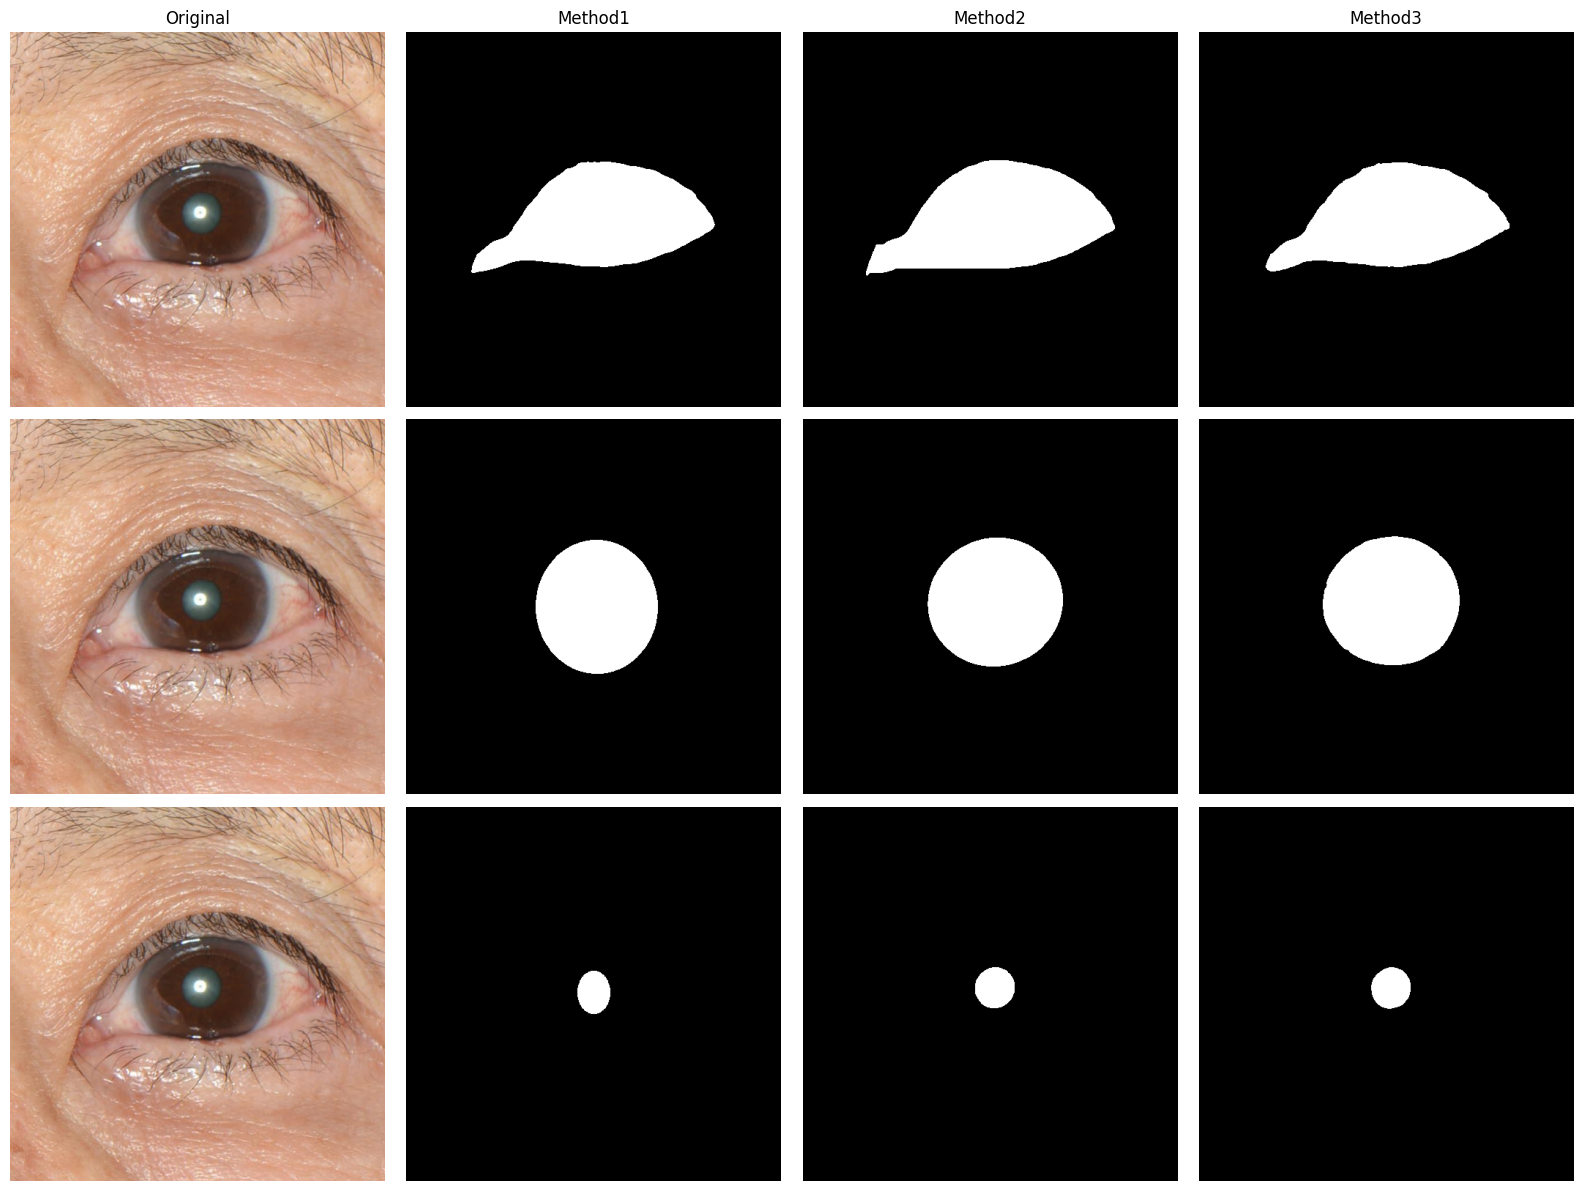


サンプル: 141-20150401-9-165011_9df05f1d0540bd451ed648231a816fc0a4e0e3e4d026c322dc3f4c907295a546_R.jpg


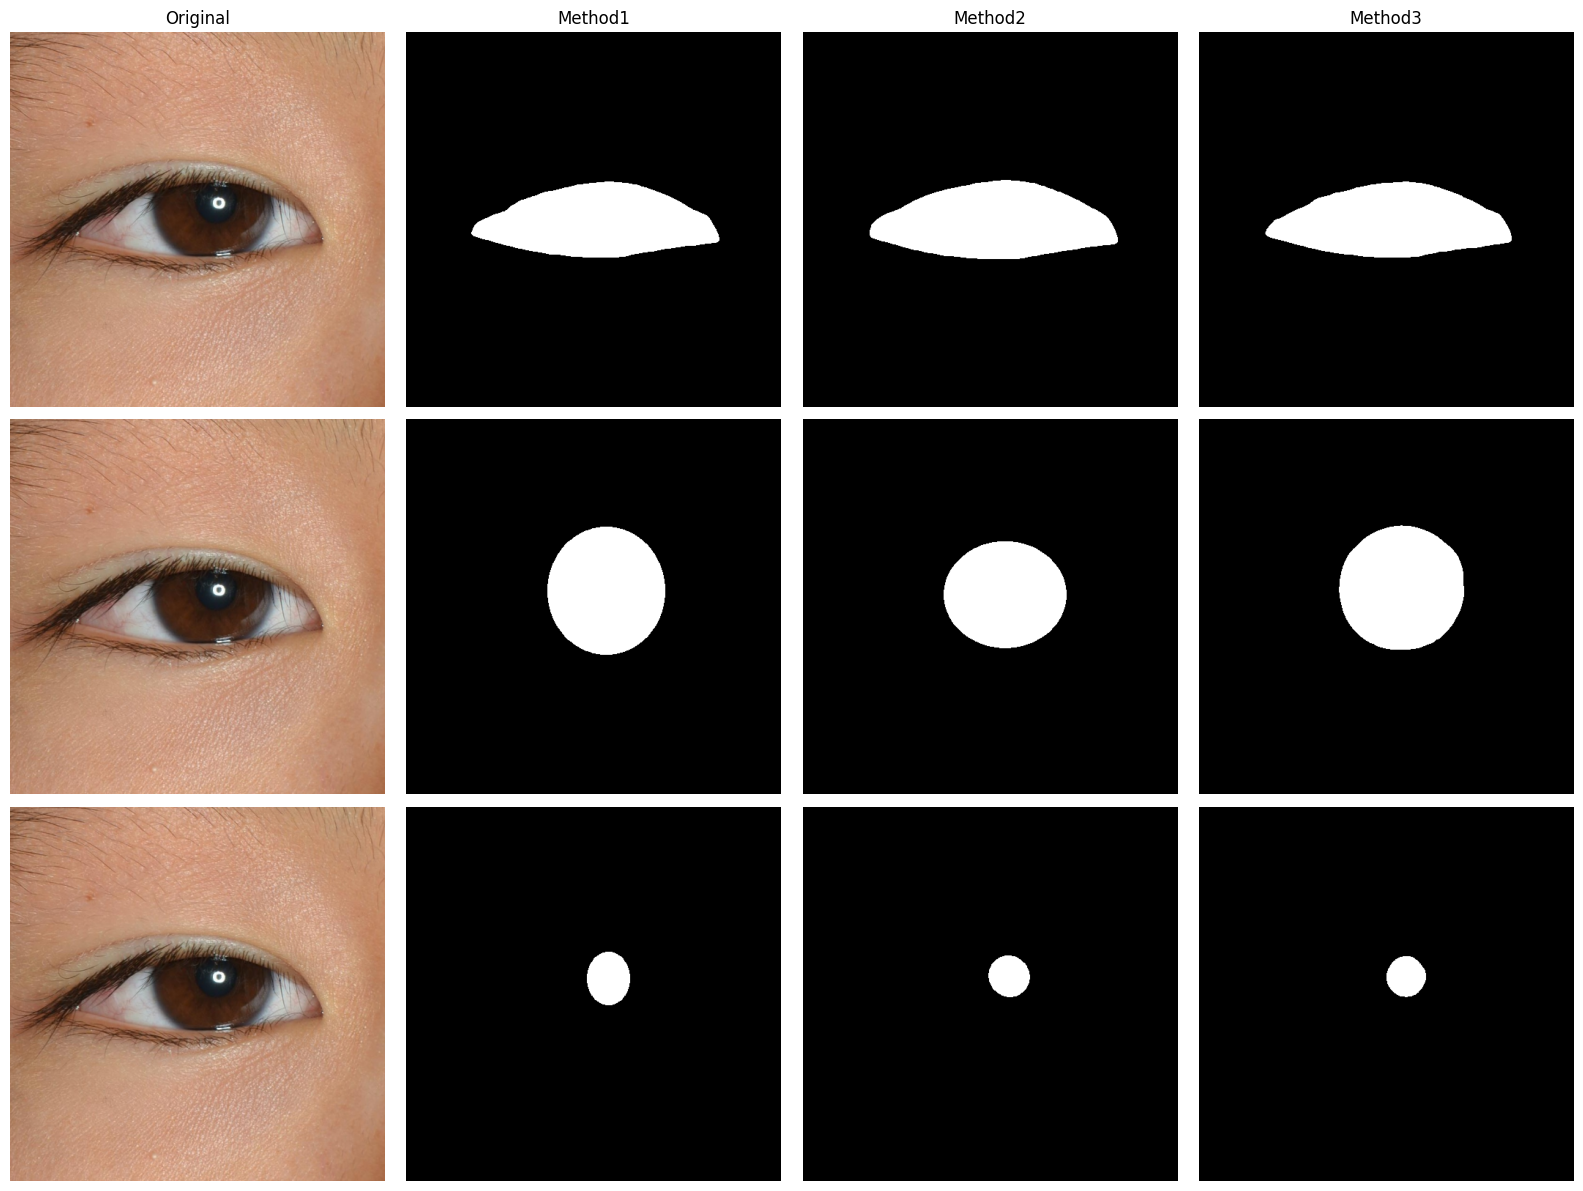


サンプル: 121-20130220-36-131934_3071b47a857a9a6409eab02812e788a5824ac7d72a96e0d5e8e46f5acc0d0eb9_L.jpg


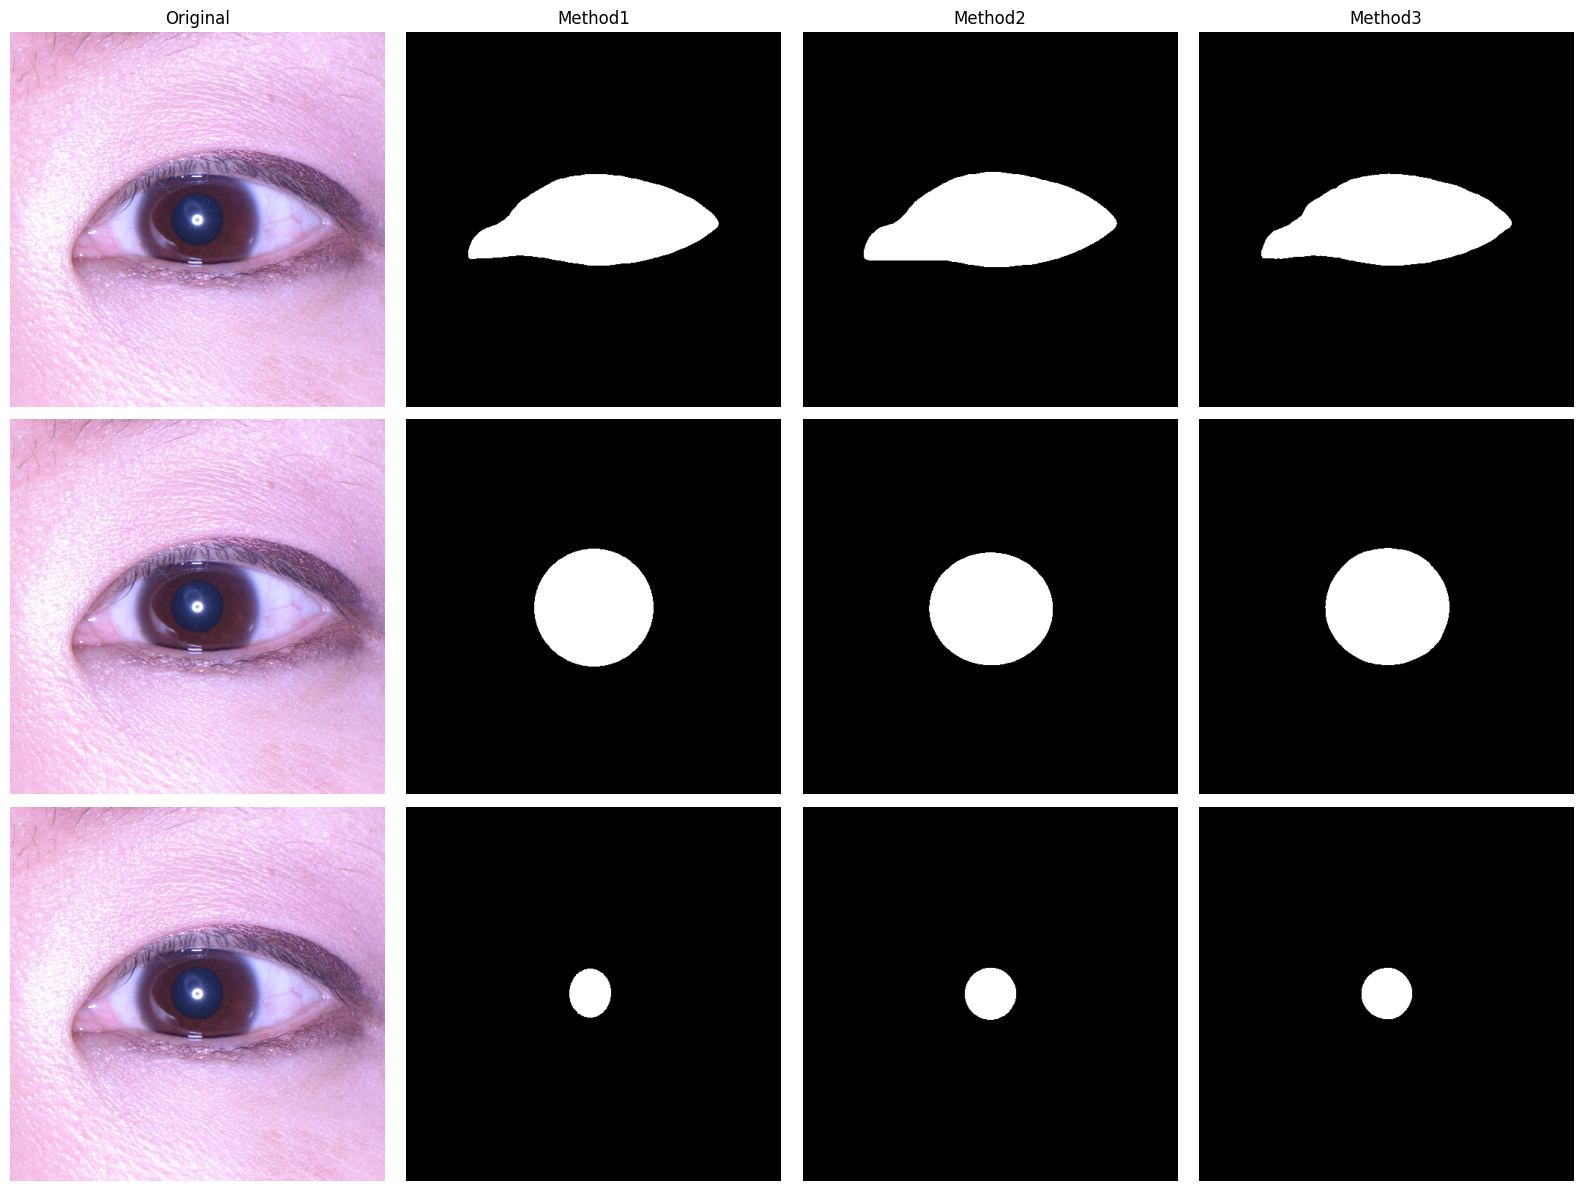


✅ 可視化完了


In [36]:
import matplotlib.pyplot as plt

# クラスカラーマップ（BGRではなくRGB）
CLASS_COLORS_RGB = {
    0: [0, 0, 0],           # 背景 - 黒
    1: [0, 0, 255],         # lid（まぶた） - 青
    2: [0, 255, 0],         # iris_vis（可視虹彩） - 緑
    3: [255, 0, 0],         # iris_occ（遮蔽虹彩） - 赤
    4: [255, 255, 0],       # pupil_vis（可視瞳孔） - 黄色
    5: [255, 0, 255],       # pupil_occ（遮蔽瞳孔） - マゼンタ
}

def create_colored_segmentation(labels):
    """6クラスのラベルマップをRGB画像に変換"""
    H, W = labels.shape
    colored = np.zeros((H, W, 3), dtype=np.uint8)
    
    for class_id, color in CLASS_COLORS_RGB.items():
        mask = labels == class_id
        colored[mask] = color
    
    return colored

def denorm_img(t):
    """正規化を戻す"""
    t = t.clone().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406])[:,None,None]
    std  = torch.tensor([0.229, 0.224, 0.225])[:,None,None]
    t = t*std + mean
    return np.clip(t.permute(1,2,0).numpy(), 0, 1)

def visualize_all_methods(sample, models, device):
    """3つのメソッドすべてを比較可視化（Original | M1 | M2 | M3）"""
    img_t = sample['image'].unsqueeze(0).to(device)
    img_vis = denorm_img(sample['image'])
    
    # 可視化用画像（Eyelid, Iris, Pupilの3行）
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    # 列タイトル
    col_titles = ['Original', 'Method1', 'Method2', 'Method3']
    row_labels = ['Eyelid', 'Iris', 'Pupil']
    
    # GTマスク
    gt_lid = sample['mask_lid'].numpy()
    gt_iris = sample['mask_iris'].numpy()
    gt_pupil = sample['mask_pupil'].numpy()
    
    # === Method1の予測 ===
    if 1 in models and models[1] is not None:
        models[1].eval()
        with torch.no_grad(), autocast():
            out1 = models[1](img_t)
        
        lid1 = (torch.sigmoid(out1['eyelid_seg'][0:1]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
        iris_params = torch.sigmoid(out1['iris_ellipse']).cpu().numpy()[0]
        pupil_params = torch.sigmoid(out1['pupil_ellipse']).cpu().numpy()[0]
        iris1 = ellipse_params_to_mask(iris_params, IMAGE_HEIGHT, IMAGE_WIDTH)
        pupil1 = ellipse_params_to_mask(pupil_params, IMAGE_HEIGHT, IMAGE_WIDTH)
    else:
        lid1 = iris1 = pupil1 = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
    
    # === Method2の予測 ===
    if 2 in models and models[2] is not None:
        models[2].eval()
        with torch.no_grad(), autocast():
            out2 = models[2](img_t)
            edge_logits = out2['edge_logits']
        
        lid_edge = (torch.sigmoid(edge_logits[0,0:1]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
        lid2 = bin_edge_to_filled(lid_edge)
        
        iris_edge = (torch.sigmoid(edge_logits[0,1:2]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
        pupil_edge = (torch.sigmoid(edge_logits[0,2:3]).cpu().squeeze().numpy() >= 0.5).astype(np.uint8)*255
        
        iris2 = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
        pupil2 = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
        
        iris_pts = np.column_stack(np.where(iris_edge > 0))
        if len(iris_pts) >= 5:
            try:
                ellipse = cv2.fitEllipse(iris_pts[:, ::-1].astype(np.int32))
                cv2.ellipse(iris2, ellipse, 255, thickness=-1)
            except: pass
        
        pupil_pts = np.column_stack(np.where(pupil_edge > 0))
        if len(pupil_pts) >= 5:
            try:
                ellipse = cv2.fitEllipse(pupil_pts[:, ::-1].astype(np.int32))
                cv2.ellipse(pupil2, ellipse, 255, thickness=-1)
            except: pass
    else:
        lid2 = iris2 = pupil2 = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
    
    # === Method3の予測 ===
    if 3 in models and models[3] is not None:
        models[3].eval()
        with torch.no_grad(), autocast():
            out3 = models[3](img_t)
            logits = out3['five_class_seg']
        
        pred = torch.argmax(logits, dim=1).cpu().numpy()[0]
        lid3 = (((pred==1) | (pred==2) | (pred==4)).astype(np.uint8)*255)
        
        # Iris: 6クラスから合成 (class 2 ∪ 3) → 楕円近似
        iris_m3_bin = (((pred==2) | (pred==3)).astype(np.uint8)*255)
        # Pupil: 6クラスから合成 (class 4 ∪ 5) → 楕円近似
        pupil_m3_bin = (((pred==4) | (pred==5)).astype(np.uint8)*255)
        
        # 楕円近似：面マスク→エッジ抽出→RANSAC→楕円マスク
        iris_m3_edge = mask_to_edge(iris_m3_bin, thickness=3)
        pupil_m3_edge = mask_to_edge(pupil_m3_bin, thickness=3)
        iris_params3  = binary_to_ellipse_params(iris_m3_edge)
        pupil_params3 = binary_to_ellipse_params(pupil_m3_edge)
        iris_mask_m3  = ellipse_params_to_mask(iris_params3,  IMAGE_HEIGHT, IMAGE_WIDTH) if iris_params3 is not None else np.zeros((IMAGE_HEIGHT,IMAGE_WIDTH), np.uint8)
        pupil_mask_m3 = ellipse_params_to_mask(pupil_params3, IMAGE_HEIGHT, IMAGE_WIDTH) if pupil_params3 is not None else np.zeros((IMAGE_HEIGHT,IMAGE_WIDTH), np.uint8)
        
        # 合成マスク（楕円近似前）と楕円マスク（楕円近似後）を重ねて表示
        iris3 = np.maximum(iris_m3_bin, iris_mask_m3)  # 両方を含める
        pupil3 = np.maximum(pupil_m3_bin, pupil_mask_m3)  # 両方を含める
    else:
        lid3 = iris3 = pupil3 = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), np.uint8)
    
    # === 描画 ===
    # Row 0: Eyelid
    axes[0,0].imshow(img_vis); axes[0,0].set_title(col_titles[0]); axes[0,0].axis('off')
    axes[0,0].set_ylabel(row_labels[0], fontsize=12, fontweight='bold')
    axes[0,1].imshow(lid1, cmap='gray'); axes[0,1].set_title(col_titles[1]); axes[0,1].axis('off')
    axes[0,2].imshow(lid2, cmap='gray'); axes[0,2].set_title(col_titles[2]); axes[0,2].axis('off')
    axes[0,3].imshow(lid3, cmap='gray'); axes[0,3].set_title(col_titles[3]); axes[0,3].axis('off')
    
    # Row 1: Iris
    axes[1,0].imshow(img_vis); axes[1,0].axis('off')
    axes[1,0].set_ylabel(row_labels[1], fontsize=12, fontweight='bold')
    axes[1,1].imshow(iris1, cmap='gray'); axes[1,1].axis('off')
    axes[1,2].imshow(iris2, cmap='gray'); axes[1,2].axis('off')
    axes[1,3].imshow(iris3, cmap='gray'); axes[1,3].axis('off')
    
    # Row 2: Pupil
    axes[2,0].imshow(img_vis); axes[2,0].axis('off')
    axes[2,0].set_ylabel(row_labels[2], fontsize=12, fontweight='bold')
    axes[2,1].imshow(pupil1, cmap='gray'); axes[2,1].axis('off')
    axes[2,2].imshow(pupil2, cmap='gray'); axes[2,2].axis('off')
    axes[2,3].imshow(pupil3, cmap='gray'); axes[2,3].axis('off')
    
    plt.tight_layout()
    plt.show()

# Fold 0の3つのメソッドのモデルで3サンプル可視化
print("3手法比較可視化 (Fold 0のモデルを使用)")
print("=" * 60)

# モデルロード
models = {}
for method_id in TRAIN_METHODS:
    model_path = MODEL_DIR / f"method{method_id}_fold0_best.pth"
    if model_path.exists():
        if method_id == 1:
            model = UNetMethod1().to(device)
        elif method_id == 2:
            model = UNetMethod2().to(device)
        else:
            model = UNetMethod3().to(device)
        
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
        model.eval()
        models[method_id] = model
    else:
        print(f"⚠️ Method{method_id} モデルが見つかりません: {model_path}")
        models[method_id] = None

if len(models) > 0:
    # Validation データセット準備
    val_indices = fold_indices['0']['val']
    val_paths = [image_paths[i] for i in val_indices]
    val_ds = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR, transform=False)
    
    # ランダムに3サンプル表示
    import random
    sample_indices = random.sample(range(len(val_ds)), min(3, len(val_ds)))
    
    for idx in sample_indices:
        sample = val_ds[idx]
        print(f"\nサンプル: {sample['filename']}")
        visualize_all_methods(sample, models, device)
    
    for model in models.values():
        if model is not None:
            del model
    del val_ds
    torch.cuda.empty_cache()
    print("\n✅ 可視化完了")
else:
    print("⚠️ モデルが見つかりません")
    print("   学習セル（セル12）を実行してモデルを作成してください。")


## 14. メモリクリア（オプション）


In [14]:
import gc

# CUDAキャッシュをクリア
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("✓ CUDA cache cleared")

# ガベージコレクション
gc.collect()
print("✓ Python garbage collection completed")

print("\n=== メモリクリア完了 ===")


✓ CUDA cache cleared
✓ Python garbage collection completed

=== メモリクリア完了 ===
